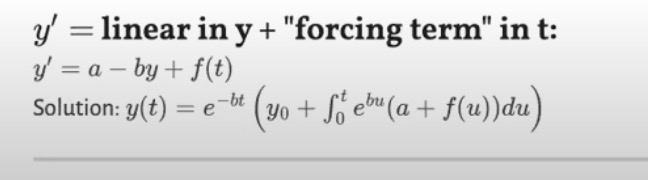

### Theory of Weight Estimation Versus Dynamics Control Tradeoff

Main thesis is that stimulating with random preturbations may allow you to infer the weights of the underlying network well but obviously gives very uninteresting dynamics (as its just a stochastic noise process). So you can't get very good control of neural dynamics (which is what the whole field nonlienar control algorithms are designed for) but maybe what you get is good connectivity estimation. This is just an idea and I don't have the mathemtical background/maturity to truly tackle this so instead I will take an experimental and computational simulation based approach. This notebook tackles the computational simulation attempt.

---

<ins>Features of Networks<ins>
* Sparse and miminally strongly connected
  - what this means is the graph is connected i.e. can get to any node from any other node.
  - but in a way that is not densely connected.
  - check if real _C. elegans_ chemical synapse network has this feature.
  - according to Cook et al. (Nature, 2019) - yes, at least weakly connected
* Real-valued activity
  - we know neural activity in the real-world is often intepreted as spikes or rates (which are non-negative values)
  - it is reasonable for us to use real-valued activity because:
    - we can always normalize (e.g. z-score) our data ...
    - most signals (e.g. calcium) are measured relative to a baseline ...
    - often times we model the residual (delta or finite difference) ... <br>
    ... all of which can take negative values.
* Real-valued weights
  - for simplicity, we will start off with using **non-negative weights** because current connectome measurements are unsigned.
  - we have the option to try out real-valued weights as well.
* No self connections (autapses)
  - we think it is a mistake to include autapses because one can always model an autapse by adding an additional "tunnel" node.
* Odd-function, 1-Lipschitz, bounded nonlinearity
  - for simplicity, we will start off with the `tanh` nonlinearity because it is very analytically tractable for our purposes.
---

**Equation of a linear RNN. The "plant equation" in control.**
$$
\tau \frac{d\mathbf{x}}{dt} = -\tilde{\mathbf{M}} \mathbf{x} + \mathbf{\tilde{\mathbf{b}}}
$$

Let $\alpha = \frac{\Delta t}{\tau}$ and discretize the above equation. After some algebraic rearranging:
$$
\mathbf{x}(t+\Delta t) = \mathbf{x}(t) - \alpha \tilde{\mathbf{M}} \mathbf{x}(t) + \alpha \mathbf{\tilde{b}}(t)
$$

**NOTE:** The experimental implication of using $\alpha = \frac{\Delta t}{\tau}$ is that we need tools that can measure faster than the time constant of the fastest neuron.

Now define $\mathbf{M} = \alpha \mathbf{\tilde{M}}, \mathbf{b} = \alpha
\mathbf{\tilde{b}}$:
$$
\mathbf{x}(t+\Delta t) = (\mathbf{I} - \mathbf{M}) \mathbf{x}(t) + \mathbf{b}(t)
$$

Let $\mathbf{W} = \mathbf{I} - \mathbf{M}$, where each element $W_{ij}$ is the connection strength or "weight" from node $j$ to node $i$. Furthermore, impose that the spectral radius $\mathbf{W}$ be no greater than $1$ i.e. $\rho(\mathbf{W}) \leq 1$.
$$
\mathbf{x}(t+\Delta t) = \mathbf{W} \mathbf{x}(t) + \mathbf{b}(t)
$$

**NOTE:**  If we introduce a nonlinearity to the orginal plant equation, we will use the Taylor expansion of the nonlinearity at $x_0 = 0$:
$$
\begin{aligned}
\mathbf{x}(t+\Delta t) &= \mathbf{x}(t) - \mathbf{M} \phi(\mathbf{x}(t)) + \mathbf{b}(t) \\
&= \mathbf{x}(t) - \mathbf{M} \left( \phi(0) + \phi^{'}(0)\mathbf{x}(t) + O(\mathbf{x}^2) \right) + \mathbf{b}(t)
\end{aligned}
$$

Since we assume that the nonlinearity is an odd-function, $\phi(0) = 0$, thus:
$$
\begin{aligned}
\mathbf{x}(t+\Delta t) &\approx \mathbf{x}(t) - \mathbf{M}\phi^\prime(0)\mathbf{x}(t) + \mathbf{b}(t) \\
&= (\mathbf{I} - \mathbf{M}\phi^{'}(0)) \mathbf{x}(t) + \mathbf{b}(t)
\end{aligned}
$$

Therefore, in the case of a nonlinear plant, we should let $\mathbf{W} = \mathbf{I} - \mathbf{M}\phi^\prime(0)$.
- If $\phi^\prime(0) \approx 1$ (like with $\phi = \operatorname{tanh}$), then it is equivalent to the linear case where $\mathbf{W} = \mathbf{I} - \mathbf{M}$.

Since we have assumed that $\phi$ is 1-Lipschitz and monotonically non-decreasing, then $0 \lt \phi^\prime(0) \leq 1$. Hence, $\rho(\mathbf{I} - \mathbf{M}\phi^\prime(0)) \leq \max \left(\rho(\mathbf{I}), \rho(\mathbf{I} - \mathbf{M}) \right)$


---

Consider the original plant equation but with nonlinearity:
$$
\dot{\mathbf{x}} = -\mathbf{M} \phi(\mathbf{x}) + \mathbf{b}
$$

The Jacobian of the system $\mathbf{J} = -\mathbf{M} \phi^\prime$
 - If assume $\phi(\mathbf{x}) \approx \mathbf{Ix}$ for "small enough" $\mathbf{x}$ and thus $\phi^\prime = \mathbf{I}$ (e.g. with $\phi = \tanh$) then $\mathbf{J} = -\mathbf{M}$. See *Appendix A*.

Thus, the sytem is asymptotically stable if $\mathbf{J}$ has all eigenvalues in the left half complex-plane i.e. if $\rho(\mathbf{J}) \leq 0$:
$$
\rho(\mathbf{J}) = \rho(-\mathbf{M}) \leq 0 \rightarrow \rho(\mathbf{M}) \geq 0
$$

This imposes that $\mathbf{M}$ must be positive semidefinite i.e. $\mathbf{M} \succcurlyeq 0$. This implies that $\rho(\mathbf{W}) = \rho(\mathbf{I} - \mathbf{M}\phi^\prime(0)) \leq 1$ which is precisely the condition on the connectivity weights $\mathbf{W}$ that we imposed earlier.

Therefore, stable dynamics equates to having the spectral radius $\rho(\mathbf{W}) \leq 1$.

---

So we have a forward discrete-time dynamics equation:
$$
\mathbf{x}(t+\Delta t) = \mathbf{W} \phi(\mathbf{x}(t)) + \mathbf{b}(t)
$$

There is a sort of "dual-form" continuous-time dynamics formulation:
$$
\dot{\mathbf{x}} = -\mathbf{M} \phi(\mathbf{x}) + \mathbf{b}
$$

with the following conditions:
* $\mathbf{M}$ is positive defnite i.e. $\mathbf{M} \succ 0 \rightarrow x^\intercal \mathbf{M} x > 0, \forall x \neq 0$
* Equivalently $\mathbf{W} = \mathbf{I} - \mathbf{M}\phi^\prime(0)$ is at the "edge-of-chaos" i.e. spectral radius $\rho(\mathbf{W}) \leq 1$
* $\phi$ is an elementwise monotonically non-decreasing nonlinearity. Further constraints could be:
  - $\phi$ is an odd-function i.e. $\phi(-x) = -\phi(x)$.
  - $\phi$ is 1-Lipschitz i.e. $\| \phi(x_1) - \phi(x_2) \| \leq \|x_1 - x_2\|$.

---

We can do a Taylor series expansion of $\phi(x)$ around $x_0 = 0$.
$$
\phi(\delta x) = \phi(0) + \phi^\prime(0) \delta x + \frac{\phi^{\prime\prime}(0)}{2!}\delta x^2 + \dots
$$

**NOTE:** Any function $\phi(x)$ that is composed of exponential functions is infinitely differentiable since each derivative will also be composed of exponentials. This would include nonlinearities like $\operatorname{sigmoid}$ and $\operatorname{tanh}$ (hyperbolics are functions of exponentials).

Could we write $\phi(x)$ instead as a sum of piecewise linear functions? For example, we can approximate $\phi(x) = \tanh(x)$ as:
$$
\phi(x) =
\begin{cases}
      -1, \quad \text{if} \quad x \leq -a \\
       x, \quad \text{if} \quad |x| < a \\
      1, \quad \text{if} \quad x \geq a
\end{cases}
$$

---


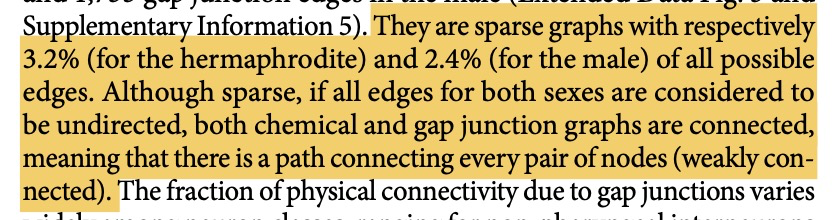

### Analysis of recurrent network system recovery from sparse data

Let us rearrange the discrete-time update equation from earlier:

$$ \mathbf{W} \phi\left(\mathbf{x}(t)\right) + \mathbf{b}(t) = \mathbf{x}(t + \Delta t)$$

in a way that makes the "push-forward" function more obvious and makes the matrix we wish to recover from the data more explicit. Interpret $\mathbf{W}_{ij}$ as the connection strength (i.e edge weight) from node $j$ to node $i$.

_N.B._ What we refer to as the "push-forward" is the function the maps from the current state at time $t$ to the subsequent state at time $t+\Delta t$.

Right multiplying on both sides by $\mathbf{x}(t)^\intercal$ gives:

$$\mathbf{W} \phi\left(\mathbf{x}(t)\right)\mathbf{x}(t)^\intercal + \mathbf{b}(t)\mathbf{x}(t)^\intercal = \mathbf{x}(t + \Delta t)\mathbf{x}(t)^\intercal $$

Since $\mathbf{x}(t)$ is a vector we know that the matrices $\phi\left(\mathbf{x}(t)\right)\mathbf{x}(t)^\intercal, \mathbf{b}(t)\mathbf{x}(t)^\intercal, \mathbf{x}(t + \Delta t)\mathbf{x}(t)^\intercal$ are all rank-$1$ and thus not invertible. But since we have multiple samples/observations/measurements of the state $\mathbf{x}(t), t \in \{0,1,2, ...,T\}$ the corresponding sample covariance matrices:

$$
\begin{aligned}
\hat{\mathbf{\Sigma}}_{\phi x} &= \frac{1}{T} \sum_{t=0}^{T}\phi \left( \mathbf{x}(t) \right) \mathbf{x}(t)^\intercal \\
\hat{\mathbf{\Sigma}}_{bx} &= \frac{1}{T} \sum_{t=0}^{T} {\mathbf{b}(t)\mathbf{x}(t)^\intercal} \\
\hat{\mathbf{\Sigma}}_{{\Delta t}x} &= \frac{1}{T} \sum_{t=0}^{T}\mathbf{x}(t + \Delta t)\mathbf{x}(t)^\intercal
\end{aligned}
$$

will be full rank, and thus invertible, if a minimal set $\geq \operatorname{dim}(\mathbf{x})$ of linearly independent states are sampled.

If suffficiently rich dynamics are present then the probability of this being true $\to 1$ as $T \to \infty$.

$$
\begin{aligned}
\hat{\mathbf{W}}\hat{\mathbf{\Sigma}}_{\phi x} + \hat{\mathbf{\Sigma}}_{bx} &= \hat{\mathbf{\Sigma}}_{\Delta tx} \\
\rightarrow \hat{\mathbf{W}}_{\text{oracle}^1} &= \left( \hat{\mathbf{\Sigma}}_{{\Delta t}x} - \hat{\mathbf{\Sigma}}_{bx} \right) \left( \hat{\mathbf{\Sigma}}_{\phi x} \right)^{-1}
\end{aligned}
$$

We can think of the external input $\mathbf{b}$ as the environment, which is impossible to measure perfectly and often not measured at all. However, we can simplify the problem of recovering the matrix $\mathbf{W}$ by assuming that the input and state are uncorrelated $\hat{\mathbf{\Sigma}}_{bx} = \mathbf{0}$.

_N.B._ This assumption is not valid in the real world but is somewhat reasonable. It essentially says that the environment is independent of the network state.

We need one further assumption. Since the true nonlinear function is unknown to the observer, we make the linear approximation $\phi(x) \approx x$ for small $x$, replacing $\hat{\mathbf{\Sigma}}_{\phi x}$ with the covariance matrix $\hat{\mathbf{\Sigma}}_{x}$ instead:
$$
\hat{\mathbf{\Sigma}}_{x} = \frac{1}{T} \sum_{t=0}^{T}\mathbf{x}(t)\mathbf{x}(t)^\intercal
$$

With the above assumptions, the equation for recovering the matrix $\mathbf{W}$ from measurement data simplifies to:
$$
\hat{\mathbf{W}}_\text{approx} = \hat{\mathbf{\Sigma}}_{\Delta tx} \left( \hat{\mathbf{\Sigma}}_x \right)^{-1}
$$

---


### What if we right-multiplied by $\mathbf{b}(t)$?

If we instead multiplied on the right by $\mathbf{b}(t)^\intercal$:

$$
\begin{aligned}
\mathbf{W} \phi\left(\mathbf{x}(t)\right)\mathbf{b}(t)^\intercal + \mathbf{b}(t)\mathbf{b}(t)^\intercal &= \mathbf{x}(t + \Delta t)\mathbf{b}(t)^\intercal
\\
\rightarrow \hat{\mathbf{W}} \hat{\mathbf{\Sigma}}_{\phi b} + \hat{\mathbf{\Sigma}}_{b}  &= \hat{\mathbf{\Sigma}}_{\Delta tb}
\end{aligned}
$$

We therefore get a second oracle:

$$
\hat{\mathbf{W}}_{\text{oracle}^2} = \left( \hat{\mathbf{\Sigma}}_{\Delta tb} - \hat{\mathbf{\Sigma}}_{b} \right) \left( \hat{\mathbf{\Sigma}}_{\phi b} \right)^{-1}
$$

---

### What if we right-multiplied $\mathbf{x}(t+\Delta t)$?

If we instead multiplied on the right by $\mathbf{b}(t)^\intercal$:

$$
\begin{aligned}
\mathbf{W} \phi\left(\mathbf{x}(t)\right)\mathbf{x}(t+\Delta t)^\intercal + \mathbf{b}(t)\mathbf{x}(t+\Delta t)^\intercal &= \mathbf{x}(t + \Delta t)\mathbf{x}(t+\Delta t)^\intercal
\\
\rightarrow \hat{\mathbf{W}} \hat{\mathbf{\Sigma}}_{\phi \Delta t} + \hat{\mathbf{\Sigma}}_{b \Delta t}  &= \hat{\mathbf{\Sigma}}_{\Delta t}
\end{aligned}
$$

This gives us yet a third oracle:

$$
\hat{\mathbf{W}}_{\text{oracle}^3} = \left( \hat{\mathbf{\Sigma}}_{\Delta t} - \hat{\mathbf{\Sigma}}_{b \Delta t} \right) \left( \hat{\mathbf{\Sigma}}_{\phi \Delta t} \right)^{-1}
$$

---

**What is strange is that these two oracles above epiricially DON'T WORK as well as the approximation $\hat{\mathbf{W}}_\text{approx}$.** Why? No clue.

Note that the `sigmoid` function centered at `0`:
$$
\phi(x) = \text{sigmoid}(x) = \frac{\exp(x) - 1}{\exp(x) + 1}
$$

is mathematically equivalent to the hyperbolic tangent function applied to half its argument:

$$
\phi(x) = \tanh\left(\frac{x}{2}\right)
$$

---

### Exploring recovering connectivity from sparse measurement data

**What does it take to reverse engineer a worm: Power and friends**

Running perturbation experiments to reverse engineer the input output functions of all neurons in *C. elegan*s has recently been proposed as a strategy towards whole nervous system emulation. However, this leads to difficult inverse problems where causal interactions have to be inferred from measurement data. Here we ask how hard it is to reverse engineer such systems using both theoretical and experimental approaches. We find that reverse engineering benefits considerably from stimulation, requires the ability to integrate experimental data across animals, and should require thousands of experiments. Nonetheless, the resulting numbers should allow reverse engineering the neuronal input output functions under relatively moderate simplifying assumptions about the structure and underlying dynamics of the *C. elegans* neural network.

---

The connectome of *C. elegans* is thought to be roughly the same across genotype and age matched animals, yet how that connectivity ultimately determines neural dynamics and behavior across different animals is unknown. We consider the problem of reverse engineering the nervous system of *C. elegans* as a systems identification problem where multiple partially measured instances of the dynamics of a common network are to be used to reconstruct the true connectivity structure. We think that this work is important for thinking about causal structure in the brain.

---

We consider there to be a fundamental difference between "process" (biophysical) noise and "measurement" (anthropogenic) noise. Biological systems have some degree of noise intrinsic to them that is potentially useful for the system. This is what we consider to be process noise. Every instrument is subject to noise. Electrodes can pick up both biophysical (e.g. thermal noise) and anthropogenic noise (e.g. electromagnetic interference from power
lines) [Van Drongelen, 2006]. An external observer who measures a property of the biological system with imprecise instruments obtains data corrupted by measurement noise. It is important to recognize that this noise is not intrinsic to the system but it is nearly impossible to distinguish between the process noise and the measurement noise. In a simulated dynamical system, the process noise is the $\epsilon(t)$ that get added to the input at every timestep. It is process noise because the system integrates this as if it were input. However, measurement noise is never integrated by the system, only something added by the experimenter's unavoidably fallible instruments or techniques. The typical assumption is to treat this noise $\eta(t)$ as i.i.d $\forall t$.

---

The world determines the sensory inputs of the subject; the sensory input exogenously drives ongoing neural activity.

---

We don't distinguish between unmeasured and unlabeled neurons.

---

**Simulation of Synthetic Networks**:

- Generate multiple instances of synthetic networks with a shared underlying connectivity structure.
- Simulate the propagation of activity or information through these networks
over time.
- Utilize various parameters to control the network dynamics, such as the number of nodes, number of measured nodes, input strength, etc.

**Customization of Network Properties**:
    
- Ensure each network instance has a specified number of sensory and non-sensory nodes.
- Assign unique properties to nodes, such as measured versus unmeasured, and sensory versus non-sensory.

---


**Potential preliminary findings**

* Solving for the connectivity matrix is impossible without stochastic stimulation.

* Stability is essential. All our generated networks are constrained to have marginally stable dynamics. Althought that constraint on the spectral radius may not be strictly necessary given a bounded nonlinearity.

* If one can inject a significant amount of noise into the system then the weights can be recovered to an appreicable degree. The noise needs to be of sufficient "amplitude" or strength to overpower any pre-existing/ongoing stable dynamics (e.g. limit cycles) in the network.

* All our results are likely extremely trivial. Since the systems we use are stable they likely are converging to the $\mathbf{0}$ vector for most initial conditions. After we have evolved the dynamics for a while our system is basically is just stimulation driven so that the state vector $\mathbf{x}(t)$ is a Gaussian random vector (since we use Gaussian stimulation). That means that ${\mathbf{\Sigma}}_x = \mathbf{I} \rightarrow \left( \mathbf{\Sigma}_x \right)^{-1} = \mathbf{I}$ and $\mathbf{\Sigma}_{\Delta tx} = \mathbf{W} \mathbf{\Sigma}_x = \mathbf{WI} = \mathbf{W}$.

    * We adress this by using CPG nodes that ensure the network is always driven.

---
    

 ## Initial setup

In [ ]:
# !pip install -q --upgrade wandb

import torch
# Select device - prefer MPS on Mac, CUDA if available, otherwise CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"\nUsing device: {device}")

import numpy as np
import pandas as pd
import scipy as scp
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

from scipy import sparse
from typing import Union
from scipy.stats import bootstrap
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS, LocallyLinearEmbedding
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

import os
import wandb
# Login to wandb and disable code logging
wandb.login(key=os.environ.get("WANDB_API_KEY"), relogin=False)
os.environ["WANDB_DISABLE_CODE"] = "true"

import joblib
import multiprocessing as mp
# Check the number of CPUs available using two equivalent approaches
print(f"\n(os) Number of CPUs: {os.cpu_count()}\n")
print(f"\n(joblib) Number of CPUs: {joblib.cpu_count()}\n")
print(f"\n(multiprocessing) Number of CPUs: {mp.cpu_count()}\n")


Using device: mps


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/quileesimeon/.netrc
wandb: Currently logged in as: qsimeon to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



(os) Number of CPUs: 16


(joblib) Number of CPUs: 16


(multiprocessing) Number of CPUs: 16



In [ ]:
def identity(x):
    """
    Identity function to use as an activation function.
    """
    return x


def sigmoid(x):
    """
    Sigmoid-like nonlinear activation function centered at x=0.5
    and horizontal asymptotes at 0 and +1. This is equalent
    to tanh(x/2).
    """
    # NOTE: This is exactly equal to tanh(x/2)
    return 1 / ( 1 + np.exp(-x) )


def relu(x):
    """
    Rectified Linear Unit (ReLU) activation function.
    """
    return np.maximum(0, x)


def sat(x, alpha=1):
    """
    Saturation function (sat) used in nonlinear control.

    Parameters:
    x (float or numpy array): Input value(s).
    alpha (float): Threshold parameter where the function switches behavior. Default is 1.

    Returns:
    float or numpy array: Output value after applying the sat function.
    """
    if isinstance(x, np.ndarray):
        return np.where(np.abs(x) <= alpha, x, np.sign(x) * alpha)
    else:
        return x if np.abs(x) <= alpha else np.sign(x) * alpha


# Pytorch module implementations
class IdentityLayer(torch.nn.Module):
    def forward(self, x):
        return x

class SigmoidLayer(torch.nn.Module):
    def forward(self, x):
        return torch.sigmoid(x)

class ReLULayer(torch.nn.Module):
    def forward(self, x):
        return torch.relu(x)

class SatLayer(torch.nn.Module):
    def __init__(self, alpha=1):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return torch.where(torch.abs(x) <= self.alpha, x, torch.sign(x) * self.alpha)

class AbsoluteActivation(torch.nn.Module):
    def forward(self, x):
        return torch.abs(x)

#########################################################################################

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/var/folders/g4/frvn1w7j7y5_90c384khr9880000gn/T/ipykernel_44713/142820483.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma(x)$")


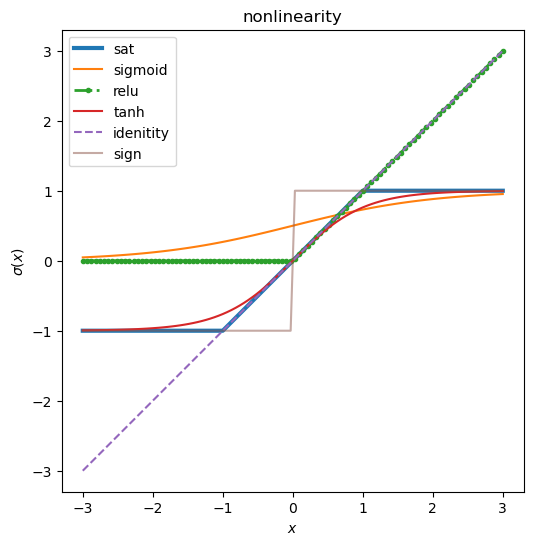

In [ ]:
### DEBUG ###
#@title Plotting what the different nonlinearities look like

x = np.linspace(-3, 3, 100)
plt.figure(figsize=(10, 6))
plt.plot(x, sat(x), label="sat", linewidth=3)
plt.plot(x, sigmoid(x), label="sigmoid")
plt.plot(x, relu(x), ".-.", label="relu", linewidth=2)
plt.plot(x, np.tanh(x), label="tanh")
plt.plot(x, identity(x), "--", label="idenitity")
plt.plot(x, np.sign(x), label="sign", alpha=0.5)
plt.xlabel("$x$")
plt.ylabel("$\sigma(x)$")
plt.legend()
plt.title("nonlinearity")
plt.axis("square")  # Set axis to square
plt.show()

### DEBUG ###

In [ ]:
def generate_chaotic_reservoir(N=100, p=0.1, g=1.3, T=2500, dt=0.1):
    """
    Returns an array chaotic_signal of shape (T, N),
    each row is the state r(t) in the reservoir.
    """

    scale = 1.0 / np.sqrt(p*N)
    # random NxN with density p
    M_sp = sparse.random(N, N, density=p, data_rvs=np.random.randn)
    M = M_sp.toarray() * g * scale  # NxN
    # we can also ensure largest eigenvalue ~ g if we want

    x = 0.1*np.random.randn(N)
    chaotic_signal = []
    for step in range(int(T)):
        # simple Euler step: x <- x + dt * (-x + M@tanh(x))
        # or use (1-dt)*x + ...
        r = np.tanh(x)
        dx = -x + M.dot(r)
        x += dt * dx
        chaotic_signal.append(x.copy())
    chaotic_signal = np.array(chaotic_signal)
    # DEBUG: normalize to zero mean and unit variance
    scaler = StandardScaler()
    chaotic_signal = scaler.fit_transform(chaotic_signal)
    return chaotic_signal  # shape (T, N)

In [ ]:
# Define the RandomNet class
class RandomNet(torch.nn.Module):
    """
    A randomly initialized neural network
    that implements a function which is periodic
    when there is zero input (autonomous) but modulated
    by inputs in a deterministic but unmodeled way.
    """

    def __init__(self, input_size, n_layers=3, layer_width=8, gain=1.0, use_chaos=True):
        super().__init__()
        self.input_size = input_size
        self.n_layers = n_layers
        self.layer_width = layer_width
        # Keep track of periods in cycle
        self.shifts = 0
        self.pi = torch.acos(torch.zeros(1)) * 2
        # Gain to attentuate/enhance output signal with
        self.gain = gain
        # Instead of simple sinusoid in absence of output
        self.use_chaos = use_chaos
        self.chaos_buffer = generate_chaotic_reservoir(N=max(input_size, 100))

        # Build up layers of the net
        layers = []
        for _ in range(n_layers):
            # No biases ensures fixed point at 0
            if _ == 0:
                # Input layer
                layer = torch.nn.Linear(input_size, layer_width, bias=False)
                torch.nn.init.normal_(
                    layer.weight, mean=0.0, std=(1.0 / input_size) ** 0.5
                )  # LeCun initialization
            else:
                # Hidden layers
                layer = torch.nn.Linear(layer_width, layer_width, bias=False)
                torch.nn.init.normal_(
                    layer.weight, mean=0.0, std=(1.0 / layer_width) ** 0.5
                )  # LeCun initialization
            layers.extend([layer, torch.nn.RMSNorm(layer_width), AbsoluteActivation()])

        # Output layer; dimension is the same as for input
        layer = torch.nn.Linear(layer_width, input_size, bias=False)
        torch.nn.init.normal_(
            layer.weight, mean=0.0, std=(1.0 / layer_width) ** 0.5
        )  # LeCun initialization
        layers.extend([layer, torch.nn.Tanh()])  # nonlinearity bounds outputs

        # Combine all layers into a sequential model
        self.model = torch.nn.Sequential(*layers)

    @torch.no_grad()
    def forward(self, x):
        """
        Rolls the state dimension so that the input to the nonlinear net is
        circularly shifting producing a periodic state-dependent function.
        Also add a time-dependent drive signal to the output.
        Esssentially this model implements a time and space varying (spatiotemporal)
        signal that will be used to continuously drive the state of a network, even
        in the absence of external inputs/stimulation.

        Args:
            x: torch.Tensor; shape: (batch, input_size)
        Returns:
            torch.Tensor; shape: (batch, input_size)
        """
        assert x.shape[-1] == self.input_size, "Input of wrong size"
        # shift the inputs circularly
        x = torch.roll(x, self.shifts, dims=-1)

        # deterministic drive
        if not self.use_chaos:
          # Original sinusoidal drive
          t = (self.shifts/(2 * self.pi) + torch.arange(self.input_size)) / self.input_size # each node gets a unique frequency
          drive = torch.sin(2 * self.pi * t).to(x.dtype).unsqueeze(0) # (1, input_size)
        else:
          # Instead pick a row from chaos_buffer
          t = self.shifts % len(self.chaos_buffer) # use self.shifts as a time index
          drive = torch.tensor(self.chaos_buffer[t, :self.input_size]).to(x.dtype).unsqueeze(0)

        # increment the count
        self.shifts += 1

        # normalize the inputs
        x = torch.nn.functional.rms_norm(x, (x.shape[-1],))

        # forward through the layers
        y = self.model(x)

        # add drive signal
        output = y + drive

        # multiply by gain factor
        output = output * self.gain
        return output

# #########################################################################################

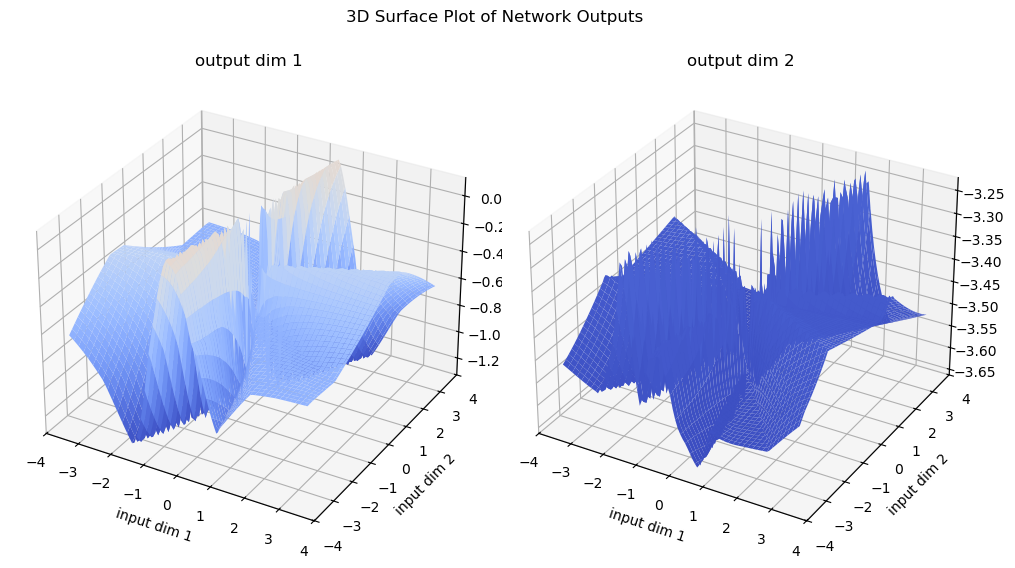

In [ ]:
### DEBUG ###
#@markdown Our RandomNet takes a $d$-dimensional input vector $x_t$ and outputs a $d$-dimensional output vector $y_t$. <br>
#@markdown We can think of the input as the state of some system at time $t$ which the RandomNet transforms. <br>
#@markdown What is different about the RandomNet is that it "rolls" the dimensions of its at each time it is called. <br>
#@markdown Thus the RandomNet output is periodic function in time for a fixed input. <br>
#@markdown So the RandomNet implements a spatiotemporal function since the output depends on both the input and the time at which the function is evaluated. <br>

# Create an instance of the network
dims = 2
net = RandomNet(input_size=dims)

# Generate 2D grid inputs from [-5, 5] x [-5, 5]
N = 100
x = torch.linspace(-3.5, 3.5, N)
y = torch.linspace(-3.5, 3.5, N)
X, Y = torch.meshgrid(x, y, indexing="ij")  # indexing='ij' to avoid shape mismatch
inputs = torch.cat([X.reshape(-1, 1), Y.reshape(-1, 1)], dim=1)  # (N, 2)

# Pass the inputs through the network
outputs = net(inputs).detach().numpy()

# ## DEBUG ###
# What if we had just used a randomly initialized LSTM to model the CPG so that output is a function of its input and history (through hidden state)?
# net2 = torch.nn.LSTM(input_size=dims, hidden_size=100, proj_size=dims, batch_first=True) # DEBUG
# net = net2
# h, c = torch.zeros(1,1,100), torch.zeros(1,1,100)
# out, (h, c)  = net2(inputs.unsqueeze(1), (h, c)) # add length dimension
# print(f"out.shape: {out.shape}")
# print(f"h.shape: {h.shape}") # DEBUG
# outputs = out.squeeze(1).detach().numpy()
# ### DEBUG ###

def plot_figure(outputs):
    # Plotting the 3D surface
    fig = plt.figure(figsize=(10, 6))
    # Choose an output coordinate to use as Z value
    out_idx = 0
    # Reshape the outputs to match the shape of the grid
    Z = outputs[:, out_idx].reshape(X.shape)
    # Find the min and max of Z to ensure 0 is centered
    z_min, z_max = Z.min(), Z.max()
    z_abs_max = max(abs(z_min), abs(z_max))
    # Adjust the color map to treat 0 as the center using `vmin` and `vmax`
    ax = fig.add_subplot(121, projection="3d")
    ax.plot_surface(
        X.numpy(),
        Y.numpy(),
        Z,
        cmap="coolwarm",
        vmin=-z_abs_max,
        vmax=z_abs_max,
        edgecolor="none",
    )
    ax.set_xlabel("input dim 1")
    ax.set_ylabel("input dim 2")
    ax.set_title(f"output dim {out_idx+1}")
    # Choose an output coordinate to use as Z value
    out_idx = 1
    # Reshape the outputs to match the shape of the grid
    Z = outputs[:, out_idx].reshape(X.shape)
    # Find the min and max of Z to ensure 0 is centered
    z_min, z_max = Z.min(), Z.max()
    z_abs_max = max(abs(z_min), abs(z_max))
    # Adjust the color map to treat 0 as the center using `vmin` and `vmax`
    ax = fig.add_subplot(122, projection="3d")
    ax.plot_surface(
        X.numpy(),
        Y.numpy(),
        Z,
        cmap="coolwarm",
        vmin=-z_abs_max,
        vmax=z_abs_max,
        edgecolor="none",
    )
    ax.set_xlabel("input dim 1")
    ax.set_ylabel("input dim 2")
    ax.set_title(f"output dim {out_idx+1}")

    plt.suptitle("3D Surface Plot of Network Outputs")
    plt.tight_layout()
    plt.show()

# plot figure
plot_figure(outputs)

### DEBUG ###

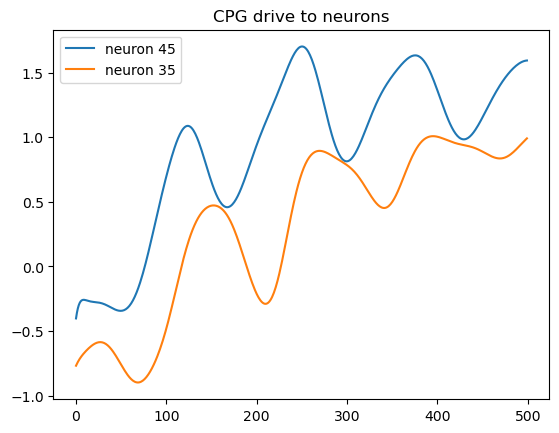

In [ ]:
### DEBUG ###

# let's test a model with high-dimension where the inputs are fixed
# we should still get the sinsuoidal drive in the outputs
state_dim = 100
net = RandomNet(input_size=state_dim)  # .double()

# ## DEBUG ###
# # What if we had just used a randomly initialized LSTM to model the CPG so that output is a function of its input and history (through hidden state)?
# net2 = torch.nn.LSTM(input_size=state_dim, hidden_size=state_dim*10, proj_size=state_dim, batch_first=True) # DEBUG
# h, c = torch.zeros(1,1,state_dim), torch.zeros(1,1,state_dim*10)
# torch.nn.init.xavier_normal_(net2.weight_hh_l0, gain=1.3) # initialize hh weight useing Xavier normal
# ### DEBUG ###

# fixed inputs to try
fixed_zeros = torch.zeros(state_dim).unsqueeze(0)
fixed_ones = torch.ones(state_dim).unsqueeze(0)
fixed_randn = torch.randn(state_dim).unsqueeze(0)
fixed_sine = torch.sin(torch.linspace(0, 5 * np.pi, state_dim)).unsqueeze(0)

# equivalent to sequence length
max_time = 500
randidx_0 = np.random.randint(0, state_dim)
randidx_1 = np.random.randint(0, state_dim)
outputs_0 = []
outputs_1 = []
for i in range(max_time):
    # input_ = fixed_randn
    # input_ = fixed_sine
    # input_ = fixed_ones
    input_ = fixed_zeros

    # ### DEBUG ###
    # output, (h, c) = net2(input_.unsqueeze(1), (h, c))
    # output = output.detach().squeeze((0,1))
    # ### DEBUG ###

    output = net(input_).detach().squeeze(0)
    outputs_0.append(output[randidx_0].item())
    outputs_1.append(output[randidx_1].item())

# we should see sinusoid
plt.figure()
plt.plot(outputs_0, label=f"neuron {randidx_0}")
plt.plot(outputs_1, label=f"neuron {randidx_1}")
plt.title("CPG drive to neurons")
plt.legend()
plt.show()

### DEBUG ###

**Possible theory/hypothesis**

Do biological networks have central pattern generators with periods proportional to the size of the network? This is what we have done in our simulation here.


In [ ]:
def create_cpg_function(state_dim, **kwargs):
    """
    Creates a nonlinear function that represents a central pattern generator (CPG).
    The function is vector-valued and parameterized as random deep neural network.
    """
    cpg_net = RandomNet(input_size=state_dim, **kwargs).double()
    cpg_net.eval()
    return cpg_net

def state_to_cpg(state, cpg_net):
    """
    Converts a state vector to a CPG vector using the provided neural network.
    """
    # convert numpy to torch
    if isinstance(state, np.ndarray):
        _state_ = torch.from_numpy(state)
    else:
        _state_ = state
    # add a batch dimension so shape is (N, dim)
    if _state_.ndim == 1:
        _input_ = _state_.unsqueeze(0)
    else:
        assert _state_.ndim == 2
        _input_ = _state_
    # get nonlinear output (no gradients)
    with torch.no_grad():
        _output_ = cpg_net(_input_).detach()
    # return same shape as _state_
    if _state_.ndim == 1:
        cpg = _output_.squeeze(0).numpy()
    else:
        cpg = _output_.squeeze(0).numpy()
    return cpg

#########################################################################################


t = 0


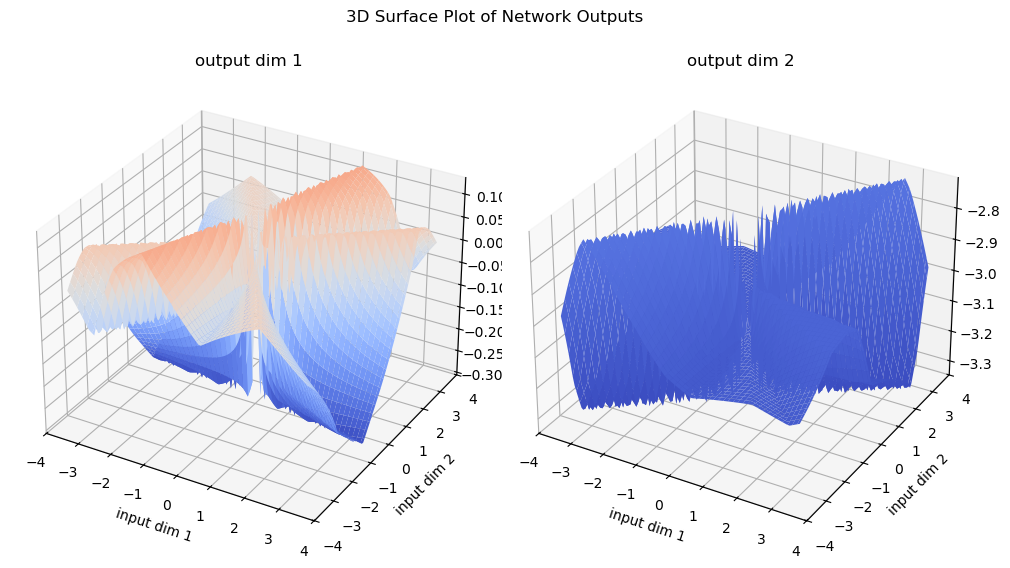

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
t = 1


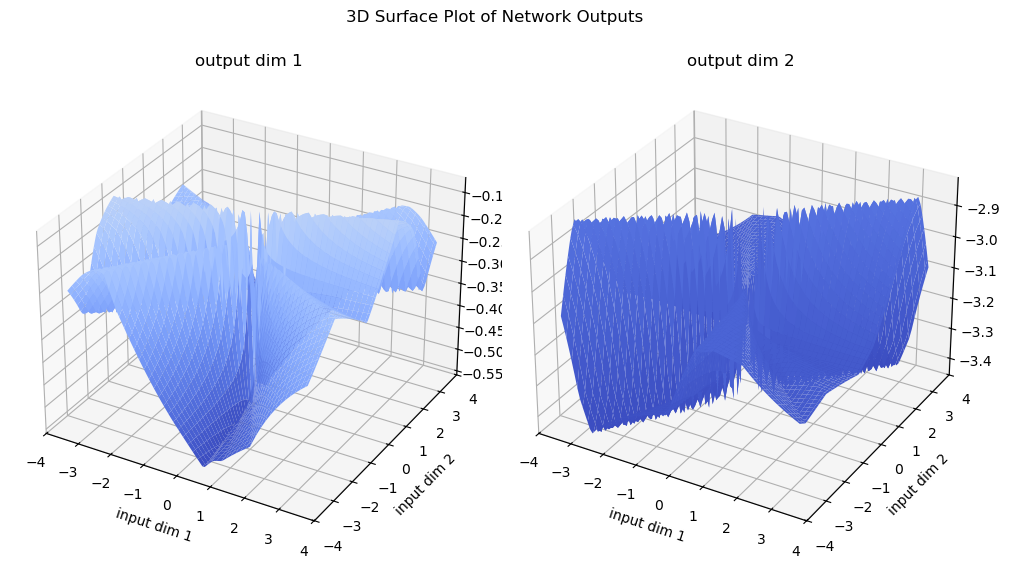

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
t = 2


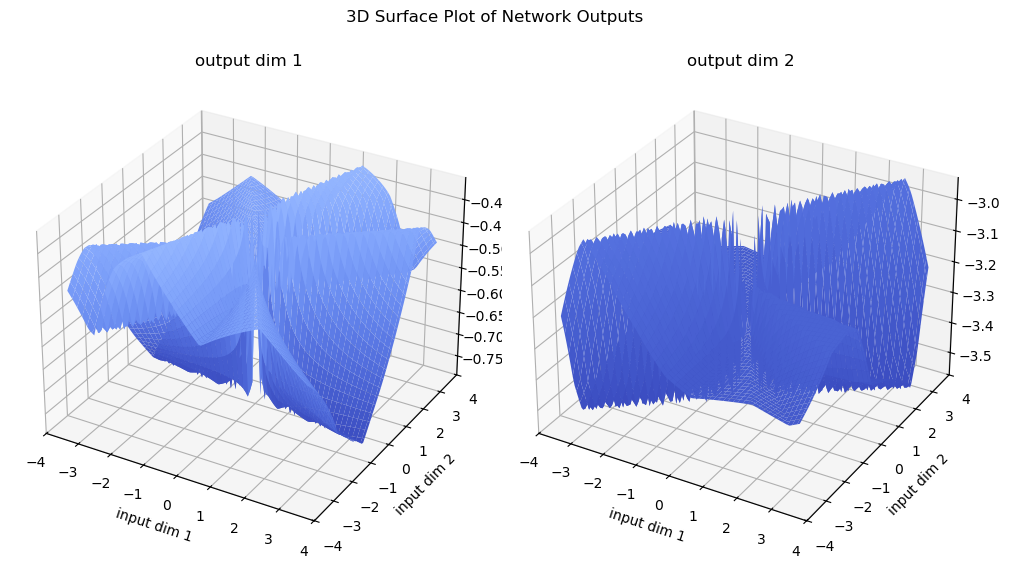

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [ ]:
# ### DEBUG ###

num_nodes = 2
cpg_net = RandomNet(input_size=num_nodes)
cpg_net.eval()

# what does the output function look like
for t in range(3):
    print(f"t = {t}")
    # inputs rolled internally so outputs are different for different timesteps
    # with period equal to the input dimension
    outputs = state_to_cpg(inputs.numpy(), cpg_net)
    plot_figure(outputs)
    print("~" * 50)

### DEBUG ###

In [ ]:
def calculate_spectral_radius(matrix):
    """
    Calculate the spectral radius of a square matrix.
    """
    assert matrix.shape[0] == matrix.shape[1], "Input matrix must be square."
    eigenvalues = np.linalg.eigvals(matrix).real
    spectral_radius = max(abs(eigenvalues))
    return spectral_radius


def adjust_spectral_radius(matrix, target_radius=1.0):
    """
    Adjust `matrix` so that its spectral radius is no more than `target_radius`.
    """
    # Multiply the matrix by a gain that adjusts its sectral norm if necessary
    eps = np.finfo(float).eps
    current_radius = calculate_spectral_radius(matrix)
    if current_radius <= target_radius - eps:
        gain = 1.0
    else:
        gain = (target_radius - eps) / current_radius
    adjusted_matrix = matrix * gain
    return adjusted_matrix

## Working pipeline code

In [ ]:
# Function for simulating data for one network
def create_network_data(
    network_idx,
    max_timesteps,
    num_nodes,
    num_cpgs,
    num_measured,
    num_sensors,
    fixed_sensors,
    stim_gain,
    nonlinearity,
    connection_weights,
):
    assert connection_weights.shape == (
        num_nodes,
        num_nodes,
    ), f"Invalid connection_weights. Got {connection_weights.shape} but expected shape ({num_nodes}, {num_nodes})."

    # print(f"\t\tCreating network data for network {network_idx} ... \n")

    # Some simulation variables
    warmup_timesteps = max_timesteps // 3
    simulation_steps = max_timesteps + warmup_timesteps

    # Initialize network data
    network = f"network{network_idx}"
    network_data = dict()
    activity_data = np.zeros((simulation_steps, num_nodes))  # zero initialization
    extrinsic_input_matrix = np.zeros_like(activity_data)
    intrinsic_input_matrix = np.zeros_like(activity_data)
    total_input_matrix = np.zeros_like(activity_data)

    # Always set the first node indices in network to be the CPGs
    # This doesn't privilege their connectivity since the networks are random but this
    # ensures the CPG is consistent across instances of the same network topology
    cpg_nodes_mask = np.zeros(num_nodes, dtype=bool)
    cpg_nodes_mask[:num_cpgs] = True  # always choose first nodes

    # Measured nodes
    measured_inds = sorted(
        np.random.choice(np.arange(num_nodes), size=num_measured, replace=False)
    )  # without replacement
    measured_nodes_mask = np.zeros(num_nodes, dtype=bool)
    measured_nodes_mask[measured_inds] = True
    node_to_index = {
        (f"node_{idx}" if idx in set(measured_inds) else str(idx)): idx
        for idx in range(1, num_nodes)
    }
    index_to_node = {idx: node for node, idx in node_to_index.items()}

    # Get spectral radius, sparsity and adjacency matrix and network graph from the connection weighs
    # NOTE: W_ij = connection_weights[i,j] is weight from node j to node i.
    spectral_radius = calculate_spectral_radius(connection_weights)
    adjacency_matrix = (np.abs(connection_weights) > 0).astype(int)
    density = np.count_nonzero(adjacency_matrix) / adjacency_matrix.size
    sparsity = 1 - density
    networkx_graph = nx.from_numpy_array(
        A=connection_weights.T, create_using=nx.DiGraph, edge_attr="weight"
    )
    # NOTE: In our simulations we multiply the state by connection_weights, which means  each row
    # connection_weights[i,:] directs the values of the network (node j's) into node i (i.e. each row has incoming conections).
    # For directed graphs in networkx, entry A[i,j] corresponds to an edge from i to j; we transpose so that A=connection_weights.T.

    # Sensors are nodes that receive stimulation
    if fixed_sensors:
        # same input nodes for all network instances
        sensor_inds = np.arange(num_nodes)[-num_sensors:].tolist()
    else:
        # different input nodes for each network instance
        sensor_inds = sorted(
            np.random.choice(np.arange(num_nodes), size=num_sensors, replace=False)
        )  # without replacement
    sensor_nodes_mask = np.zeros(num_nodes, dtype=bool)
    sensor_nodes_mask[sensor_inds] = True

    # Evolve/unfold/propagate the dynamics through the network
    # NOTE: We simulate the dynamics with CPG nodes embedded in the network,
    # emulating some nonlinear underlying/latent process that is unobservable to us.
    for t in range(simulation_steps):
        # Stimulation is meant to perturb the network with independent Gaussian noise
        stimulation = np.random.normal(loc=0.0, scale=stim_gain, size=num_nodes)

        # Update step / recurrence relation
        if t == 0:
            # The CPG is meant to emulate intrinsic nonlinear drive that is time-dependent, state-modulated
            # but for which we don't have a good analytical model so we use a random deep neural net
            # e.g. physical interpretations are energy-dynamics, blood-oxygen flow, pacemakers, etc.
            # If the state modulation is null, the CPG is a periodic signal.
            cpg_net = create_cpg_function(state_dim=num_nodes)
            extrinsic_drive = np.zeros(num_nodes)
            intrinsic_drive = np.zeros(num_nodes)
            total_input = extrinsic_drive + intrinsic_drive
            state = np.random.uniform(
                low=-5.0, high=5.0, size=num_nodes
            )  # random initial state
        else:
            # Inputs are the sum of CPG pattern and stimulations applied at "sensory" nodes
            central_pattern = state_to_cpg(
                state, cpg_net
            )  # NOTE: Need this to be contracting.
            extrinsic_drive = sensor_nodes_mask * stimulation
            intrinsic_drive = cpg_nodes_mask * central_pattern
            total_input = extrinsic_drive + intrinsic_drive
            state = connection_weights @ nonlinearity(state) + total_input

        # Store the network state (i.e activations) and inputs
        activity_data[t][measured_inds] = state[
            measured_inds
        ]  # only measured/observed nodes have activity recorded
        extrinsic_input_matrix[t] = extrinsic_drive
        intrinsic_input_matrix[t] = intrinsic_drive
        total_input_matrix[t] = total_input

    # Discard the warmup timesteps
    activity_data = activity_data[warmup_timesteps:]
    extrinsic_input_matrix = extrinsic_input_matrix[warmup_timesteps:]
    intrinsic_input_matrix = intrinsic_input_matrix[warmup_timesteps:]
    total_input_matrix = total_input_matrix[warmup_timesteps:]

    # # DEBUG: Standardize the activity data
    # scaler = StandardScaler()
    # activity_data = scaler.fit_transform(activity_data)

    # Save the data in a dictionary
    network_data["network"] = network
    network_data["activity_data"] = activity_data
    network_data["max_timesteps"] = max_timesteps
    network_data["node_to_index"] = node_to_index
    network_data["index_to_node"] = index_to_node
    network_data["num_nodes"] = num_nodes
    network_data["measured_nodes_mask"] = measured_nodes_mask
    network_data["sensor_nodes_mask"] = sensor_nodes_mask
    network_data["cpg_nodes_mask"] = cpg_nodes_mask
    network_data["connection_weights"] = connection_weights
    network_data["spectral_radius"] = spectral_radius
    network_data["adjacency_matrix"] = adjacency_matrix
    network_data["density"] = density
    network_data["sparsity"] = sparsity
    network_data["networkx_graph"] = networkx_graph
    network_data["extrinsic_input_matrix"] = extrinsic_input_matrix
    network_data["intrinsic_input_matrix"] = intrinsic_input_matrix
    network_data["total_input_matrix"] = total_input_matrix
    network_data["nonlinearity"] = nonlinearity
    network_data["stim_gain"] = stim_gain
    network_data[
        "extra_info"
    ] = """The underlying network is ensured to be a connected graph (i.e. one component).\n
    In the absence of external stimulation, the network is intrinsically driven by a central pattern generator (CPG).\n
    This is an intrinsic driving force meant to represent ongoing but unmodeled stable quasi-periodic neural dynamics.\n
    The CPG is simulated as intrinsically driven nonlinear input generated by a random deep network.\n
    Stimulation to specified sensory nodes is in the form of i.i.d samples with mean 0 and scale `stim_gain`.\n
    The stimulation is 0-mean Gaussian noise meant to perturb the dynamics of the network away from equilibrium.\n
    The external drive to any node is any stimulation applied if that node is a sensory node.\n
    The intrinsic drive to any node is the CPG pattern if that node is the a CPG node.\n
    The total input to any node the the sum of the extrinsic and intrinsic drive.
    The combined input of the whole network (i.e. the total input to every node) is stored in `total_input_matrix `.\n
    The measured activity of observed nodes is stored in the (time, num_nodes) matrix `activity_data`.\n
    The connectivity weights will be non-negative sampled from Unif(0,1) if `non_negative_weights` is True; otherwise they will be sampled from Unif(-1,1).\n
    The activity of nodes can take any real value.\n
    `total_input_matrix` is a matrix with the same shape as `activity_data` (time, num_nodes) where each row is the pattern of total input to the network at time t.\n
    `adjacency_matrix` is binary square (num_nodes, num_nodes) matrix representing a directed graph.\n
    `connection_weights` is the same shape as `adjacency_matrix` but contains float values for the edge weights.\n
    `spectral_radius` is the maximum absolute value of the eigenvalues of `connection_weights`.\n
    `density` a measure of how densely connected the underlying network is and is equivalent to 1-sparsity.
    `sparsity` is a measure of how sparsely connected the underlying network is and is equivalent to 1-density."""

    return network_data


#########################################################################################################################################################################################

In [ ]:
# Helper function for creating a network with random topology to simulate dynamics on
def random_network_topology(num_nodes, non_negative_weights, force_stable, strongly_connected=True):
    '''
    Creates a random network with random topology to be passed to `create_network_data`.

    :param num_nodes: The number of nodes in the network.
    :param non_negative_weights: Whether to constrain the connectivity weights to be non-negative.
    :param force_stable: Whether to constrain the spectral norm of the conenctivity to be less than 1, making the dynamics stable.
    :param strongly_connected: Whether to ensure the network is strongly connected.
    '''
    # Define a fixed minimal connectivity matrix which ensures that the network is connected.
    density = 0.0
    step = 0.001
    connected = False
    while (
        not connected
    ):
        # increment gently so we don't jump over less dense nets that are connected
        density = density + step  # maximum 100 loops
        density = min(
            density, 1.0
        )  # density should not exceed 1.0 since it is a probability
        step = 1.1 * step
        step = min(step, 1 - density)
        adjacency_matrix = np.random.choice(
            [0, 1], size=(num_nodes, num_nodes), p=[1 - density, density]
        )
        # NOTE: This removes any self-connections (i.e. autapses).
        adjacency_matrix[np.diag_indices(num_nodes)] = 0
        G = nx.from_numpy_array(
            A=adjacency_matrix.T, create_using=nx.DiGraph
        )  # directed graph
        # According Cook et al (Nature, 2019), the connectome is weakly connected *
        if not strongly_connected:
            connected = nx.is_weakly_connected(
                G
            )
        # * But using nx.is_weakly_connected(G) gave closer match to measured biological sparsity than nx.is_weakly_connected(G)
        else:
            connected = nx.is_strongly_connected(
                G
            )  # raises NetworkXNotImplemented if G is undirected.

    # NOTE: connection_weights[i,j] is the weight of the connection from node j to node i.
    eps = np.finfo(float).eps
    if non_negative_weights:
        # bounded non-negative weights sampled from Unif(0,1)
        connection_weights = adjacency_matrix * (
            eps + np.random.rand(num_nodes, num_nodes)
        )
    else:
        # bounded real-valued weights sampled from Unif(-1,1)
        connection_weights = adjacency_matrix * (
            2 * (eps + np.random.rand(num_nodes, num_nodes) - 0.5)
        )

    # NOTE: Controlling the spectral norm may not be strictly necessary if the nonlinearity is saturating.
    if force_stable:
        connection_weights = adjust_spectral_radius(
            connection_weights, target_radius=1.0
        )

    return connection_weights, adjacency_matrix

We treat our CPGs as if they are just nodes embedded in the network that we don't know about. A neuron could be a CPG but we don't know it. We don't assert any assumptions on which nodes are CPGs and don't impose any special connectivity to CPG nodes. Think of the CPGs are nodes that just happen to have their own autonomus drive that we are not able to model. We don't privilege them in any way; they could end up being stimulated (sensor) and/or measured.

In [ ]:
# Function for simulating data from multiple instance networks with the same underlying connectivity
def create_multinetwork_dataset(
    num_networks,
    max_timesteps,
    num_nodes,
    num_cpgs,
    num_measured,
    num_sensors,
    fixed_sensors,
    stim_gain,
    nonlinearity,
    non_negative_weights,
    force_stable,
):
    """
    Creates a dataset of multiple synthetic network instances with the same underlying connectivity.

    :param num_networks: The number of synthetic network instances to create.
    :param max_timesteps: The number of timepoints of activity data to generate.
    :param num_nodes: The total number of nodes in the network. An upper bound on the number of measured nodes.
    :param num_cpgs: The number of nodes that will be central pattern generators (CPGs).
    :param num_measured: The number of nodes to measure in each network instance.
    :param num_sensors: The number of nodes that will constitute the sensory interface and thus receive stimulation.
    :param fixed_sensors: Whether to use the same sensory nodes for all networks.
    :param stim_gain: The standard deviation of the iid Gaussian stimulation.
    :param nonlinearity: The nonlinear function to use for every node in the network.
    :param non_negative_weights: Whether to constrain the connectivity weights to be non-negative.
    :param force_stable: Whether to constrain the spectral norm of the conenctivity to be less than 1, making the dynamics stable.
    :return: A dictionary containing the synthetic network instances with data evolved on each.

    num_networks: int = 1
    max_timesteps: int = 1000
    num_nodes: int = 3
    num_cpgs: int = 1
    num_measured: None | int = int(2/3*num_nodes)
    num_sensors: None | int = int(1/3*num_nodes)
    fixed_sensors: bool = False
    stim_gain: float = 1.0
    nonlinearity: callable = np.tanh # options: {np.sign, np.tanh, sat, sigmoid}
    non_negative_weights: bool = True
    force_stable: bool = True
    """
    # Do some basic assertion checks
    assert (
        max_timesteps >= 100
    ), f"Insufficent number timesteps ({max_timesteps}) for simulation."
    assert (
        num_nodes >= 2
    ), f"Number of nodes ({num_nodes}) must be greater than 2 to make a network."
    assert (
        num_sensors <= num_nodes
    ), f"Number of sensory nodes ({num_sensors}) cannot be greater than number of nodes in network ({num_nodes})."
    assert (
        num_cpgs <= num_nodes
    ), f"Number of CPG nodes ({num_cpgs}) cannot be greater than number of nodes in network ({num_nodes})."
    assert (
        num_measured <= num_nodes
    ), f"Number of measured nodes ({num_measured}) cannot be greater than number of nodes in network ({num_nodes})."
    assert (
        num_measured >= 2
    ), f"Need to measure at least 2 nodes to calculate covariance matrices but only {num_measured} was given."
    assert callable(
        nonlinearity
    ), f"The nonlinearity ({nonlinearity}) is not a callable function."

    connection_weights, adjacency_matrix = random_network_topology(
        num_nodes, non_negative_weights, force_stable
    )

    # Create data for each network instance in parallel
    # print(f"\tMaking dataset of multiple network instances ... \n")
    results = joblib.Parallel(n_jobs=-2, verbose=1)(
        joblib.delayed(create_network_data)(
            network_idx,
            max_timesteps,
            num_nodes,
            num_cpgs,
            num_measured,
            num_sensors,
            fixed_sensors,
            stim_gain,
            nonlinearity,
            connection_weights,
        )
        for network_idx in range(num_networks)
    ) # joblib to parallelize network creation
    # Store results in a dictionary
    dataset = {res["network"]: res for res in results}

    return dataset

In [ ]:
# Helper function to visualize a particular network instance
def visualize_network(
    networkx_graph,
    measured_nodes_mask=None,
    sensor_nodes_mask=None,
    cpg_nodes_mask=None,
    show_fig=True,
    save_png=False,
    png_name="net_viz.png",
    layout="kamada_kawai",
):
    """
    Visualizes a network with edge thickness reflecting connection weights.

    Sensor nodes: stimulation was applied to these nodes.
    Effector nodes: nodes that were not stimulated.
        (Sensor and effector nodes are mutually exclusive.)

    CPG nodes: nodes with unmodeled autonomous activity.
        (A CPG node may be either sensor or effector.)

    Measured nodes: nodes whose activity was recorded.
    Unmeasured nodes: nodes that were not recorded.

    In this visualization:
      - The **fill color** indicates measurement:
          • green = measured
          • lightblue = unmeasured
      - The **node shape** indicates node type:
          • triangle (^) = sensor
          • circle (o) = effector
      - The **node edge color** indicates CPG status:
          • red = CPG
          • black = non-CPG
      - All linewidths are set to 1.
    """
    # Get all nodes
    all_nodes = list(networkx_graph.nodes)
    n_nodes = len(all_nodes)

    # Default masks if not provided
    if measured_nodes_mask is None:
        measured_nodes_mask = [False] * n_nodes
    if sensor_nodes_mask is None:
        sensor_nodes_mask = [False] * n_nodes
    if cpg_nodes_mask is None:
        cpg_nodes_mask = [False] * n_nodes

    # Separate sensor and effector nodes
    sensor_nodes = [n for n in all_nodes if sensor_nodes_mask[n]]
    effector_nodes = [n for n in all_nodes if not sensor_nodes_mask[n]]

    # Node fill colors
    sensor_fill = ["green" if measured_nodes_mask[n] else "lightblue" for n in sensor_nodes]
    effector_fill = ["green" if measured_nodes_mask[n] else "lightblue" for n in effector_nodes]

    # Node edge colors
    sensor_edge = ["red" if cpg_nodes_mask[n] else "black" for n in sensor_nodes]
    effector_edge = ["red" if cpg_nodes_mask[n] else "black" for n in effector_nodes]

    # Choose layout algorithm
    if layout == "spring":
        pos = nx.spring_layout(networkx_graph, k=0.3, iterations=100, seed=42)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(networkx_graph)
    elif layout == "fruchterman_reingold":
        pos = nx.fruchterman_reingold_layout(networkx_graph, scale=2)
    else:
        pos = nx.spring_layout(networkx_graph)

    plt.figure(figsize=(8, 6))

    # Draw nodes
    nx.draw_networkx_nodes(networkx_graph, pos, nodelist=sensor_nodes, node_color=sensor_fill,
                           node_shape="^", node_size=500, alpha=0.9, edgecolors=sensor_edge, linewidths=1.0)
    nx.draw_networkx_nodes(networkx_graph, pos, nodelist=effector_nodes, node_color=effector_fill,
                           node_shape="o", node_size=500, alpha=0.9, edgecolors=effector_edge, linewidths=1.0)

    # Extract edge weights
    edges, weights = zip(*nx.get_edge_attributes(networkx_graph, 'weight').items())
    edge_widths = np.interp(weights, (min(weights), max(weights)), (0.1, 1.5))  # Scale to range 0.1 to 1.5

    # Draw edges with variable thickness
    nx.draw_networkx_edges(networkx_graph, pos, edgelist=edges, width=edge_widths, alpha=0.6)

    # Draw labels
    nx.draw_networkx_labels(networkx_graph, pos, font_size=10, font_color="black")

    # Add legend
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", label="Measured", markerfacecolor="green", markersize=10),
        Line2D([0], [0], marker="o", color="w", label="Unmeasured", markerfacecolor="lightblue", markersize=10),
        Line2D([0], [0], marker="^", color="w", label="Sensor", markerfacecolor="grey", markersize=10),
        Line2D([0], [0], marker="o", color="w", label="Effector", markerfacecolor="grey", markersize=10),
        Line2D([0], [0], marker="o", color="w", label="CPG", markerfacecolor="white", markeredgecolor="red", markersize=10),
        Line2D([0], [0], marker="o", color="w", label="Non-CPG", markerfacecolor="white", markeredgecolor="black", markersize=10),
    ]
    plt.legend(handles=legend_elements, loc="best")
    plt.title(png_name.split(".")[0])
    plt.axis("off")

    if save_png:
        plt.savefig(png_name, dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
    plt.close()


In [ ]:
# Helper function to generate and save heatmaps
def generate_heatmaps(true_W, approx_W, optimA_W, total_mask, repetition_idx, ticklabels="auto"):
    # Decide based on size
    boole = true_W.shape[0] < 9
    ticklabels = ticklabels if boole else False

    # Initialize the figure
    plt.figure(figsize=(8, 6))

    # First heatmap with its own colorbar
    ax1 = plt.subplot(2, 2, 1)
    sns.heatmap(
        true_W,
        cmap="coolwarm",
        annot=boole,
        cbar=True,
        square=True,
        cbar_kws={
            "shrink": 0.5,
            "aspect": 10,
        },  # adjust colorbar size with shrink and aspect
        xticklabels=ticklabels,
        yticklabels=ticklabels,
        ax=ax1,
    )
    ax1.set(xlabel="node", ylabel="node")
    plt.title(f"True Weights (Repetition {repetition_idx})")

    # Second heatmap with its own colorbar
    ax2 = plt.subplot(2, 2, 2)
    sns.heatmap(
        np.round(approx_W, 2),
        cmap="coolwarm",
        annot=boole,
        cbar=True,
        square=True,
        cbar_kws={"shrink": 0.5, "aspect": 10},
        xticklabels=ticklabels,
        yticklabels=ticklabels,
        ax=ax2,
    )
    ax2.set(xlabel="node", ylabel="node")
    plt.title(f"Estimated Weights (Repetition {repetition_idx})")

    # Third heatmap with its own colorbar
    ax3 = plt.subplot(2, 2, 3)
    sns.heatmap(
        np.round(optimA_W, 2),
        cmap="coolwarm",
        annot=boole,
        cbar=True,
        square=True,
        cbar_kws={"shrink": 0.5, "aspect": 10},
        xticklabels=ticklabels,
        yticklabels=ticklabels,
        ax=ax3,
    )
    ax3.set(xlabel="node", ylabel="node")
    plt.title(f"Optimized Estimate (A) (Repetition {repetition_idx})")

    ### DEBUG ###
    # Fourth plot with its own colorbar
    # Create the heatmap
    ax4 = plt.subplot(2, 2, 4)
    heatmap = sns.heatmap(
                total_mask,
                cmap="viridis",
                annot=boole,
                cbar=True,
                square=True,
                cbar_kws={"shrink": 0.5, "aspect": 10},
                xticklabels=ticklabels,
                yticklabels=ticklabels,
                ax=ax4,
                )
    cbar = heatmap.collections[0].colorbar # get colorbar
    cbar.locator = ticker.MaxNLocator(integer=True)  # ensure ticks are integers
    cbar.update_ticks()  # update the colorbar with the new tick settings
    ax4.set(xlabel="node", ylabel="node")
    plt.title(f"Total Comeasurement Counts (Repetition {repetition_idx})")
    ### DEBUG ###

    # Save the figure with subplots
    plt.tight_layout()  # helps to ensure the subplots fit well within the figure
    heatmap_png = f"heatmap_rep_{repetition_idx}.png"
    plt.savefig(heatmap_png, dpi=300, bbox_inches="tight")
    plt.close()

    return heatmap_png

In [ ]:
# Helper function to generate a summary bar graph with error bars using seaborn
def generate_bar_graph(distance_df, CI_df):
    # Create a DataFrame that includes the medians and their respective confidence intervals
    df = pd.DataFrame(
        {
            "Distance Type": [
                "Chance",
                "Adjacency",
                "Spectral",
                "Estimate",
                "Optimized",
            ],
            "Median Distance": distance_df.median().values,
            "CI Lower": CI_df.loc["low"].values,
            "CI Upper": CI_df.loc["high"].values,
        }
    )

    # Calculate the error bars
    df["Error Lower"] = df["Median Distance"] - df["CI Lower"]
    df["Error Upper"] = df["CI Upper"] - df["Median Distance"]

    # Plotting with seaborn
    plt.figure(figsize=(8, 6))
    sns.barplot(
        x="Distance Type",
        y="Median Distance",
        data=df,
        errorbar=None,
        hue="Distance Type",
        palette=sns.color_palette("husl", n_colors=len(distance_df.columns)),
        legend=False,
    )
    plt.errorbar(
        x=range(len(df)),
        y=df["Median Distance"],
        yerr=[df["Error Lower"], df["Error Upper"]],
        fmt="none",
        capsize=5,
        color="black",
    )
    plt.xlabel("Distance Type")
    plt.ylabel("Frobenius Norm Distance")
    plt.title(f"Summary Distance Comparison with 95% CI")

    # Save the figure
    bar_graph_png = "bar_graph_summary.png"
    plt.savefig(bar_graph_png, dpi=300, bbox_inches="tight")
    plt.close()

    return bar_graph_png

In [ ]:
def generate_pca_plot(data_matrix, png_name):
    X = data_matrix  # (n_samples, n_features) == (T, num_nodes)
    fig = plt.figure(figsize=(20, 6))
    # data matrix X already shaped (n_samples, n_feature)
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X)
    ax = fig.add_subplot(111, projection="3d", aspect="auto")
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=range(X_pca.shape[0]), cmap="Blues")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    ax.set_zlabel("dim 3")
    ax.set_title("Network activity in PC space")
    cbar = plt.colorbar(sc, ax=ax, fraction=0.02, pad=0.1)
    cbar.set_label("time")
    # save figure
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(png_name, dpi=300, bbox_inches="tight")
    plt.close()

Here's the breakdown of what the distinction between experiment, repetition, and network is:

- 1 **experiment** = multiple *repetitions* (network size, number of stimulated & measured nodes held constant)

- 1 **repetition** = multiple *networks* (underlying connectivity & governing dynamics held constant; randomness in which nodes are measured or stimulated)

- 1 **network** = 1 *instance* (think of as one worm/animal/subject; this is the lowest level 'object')


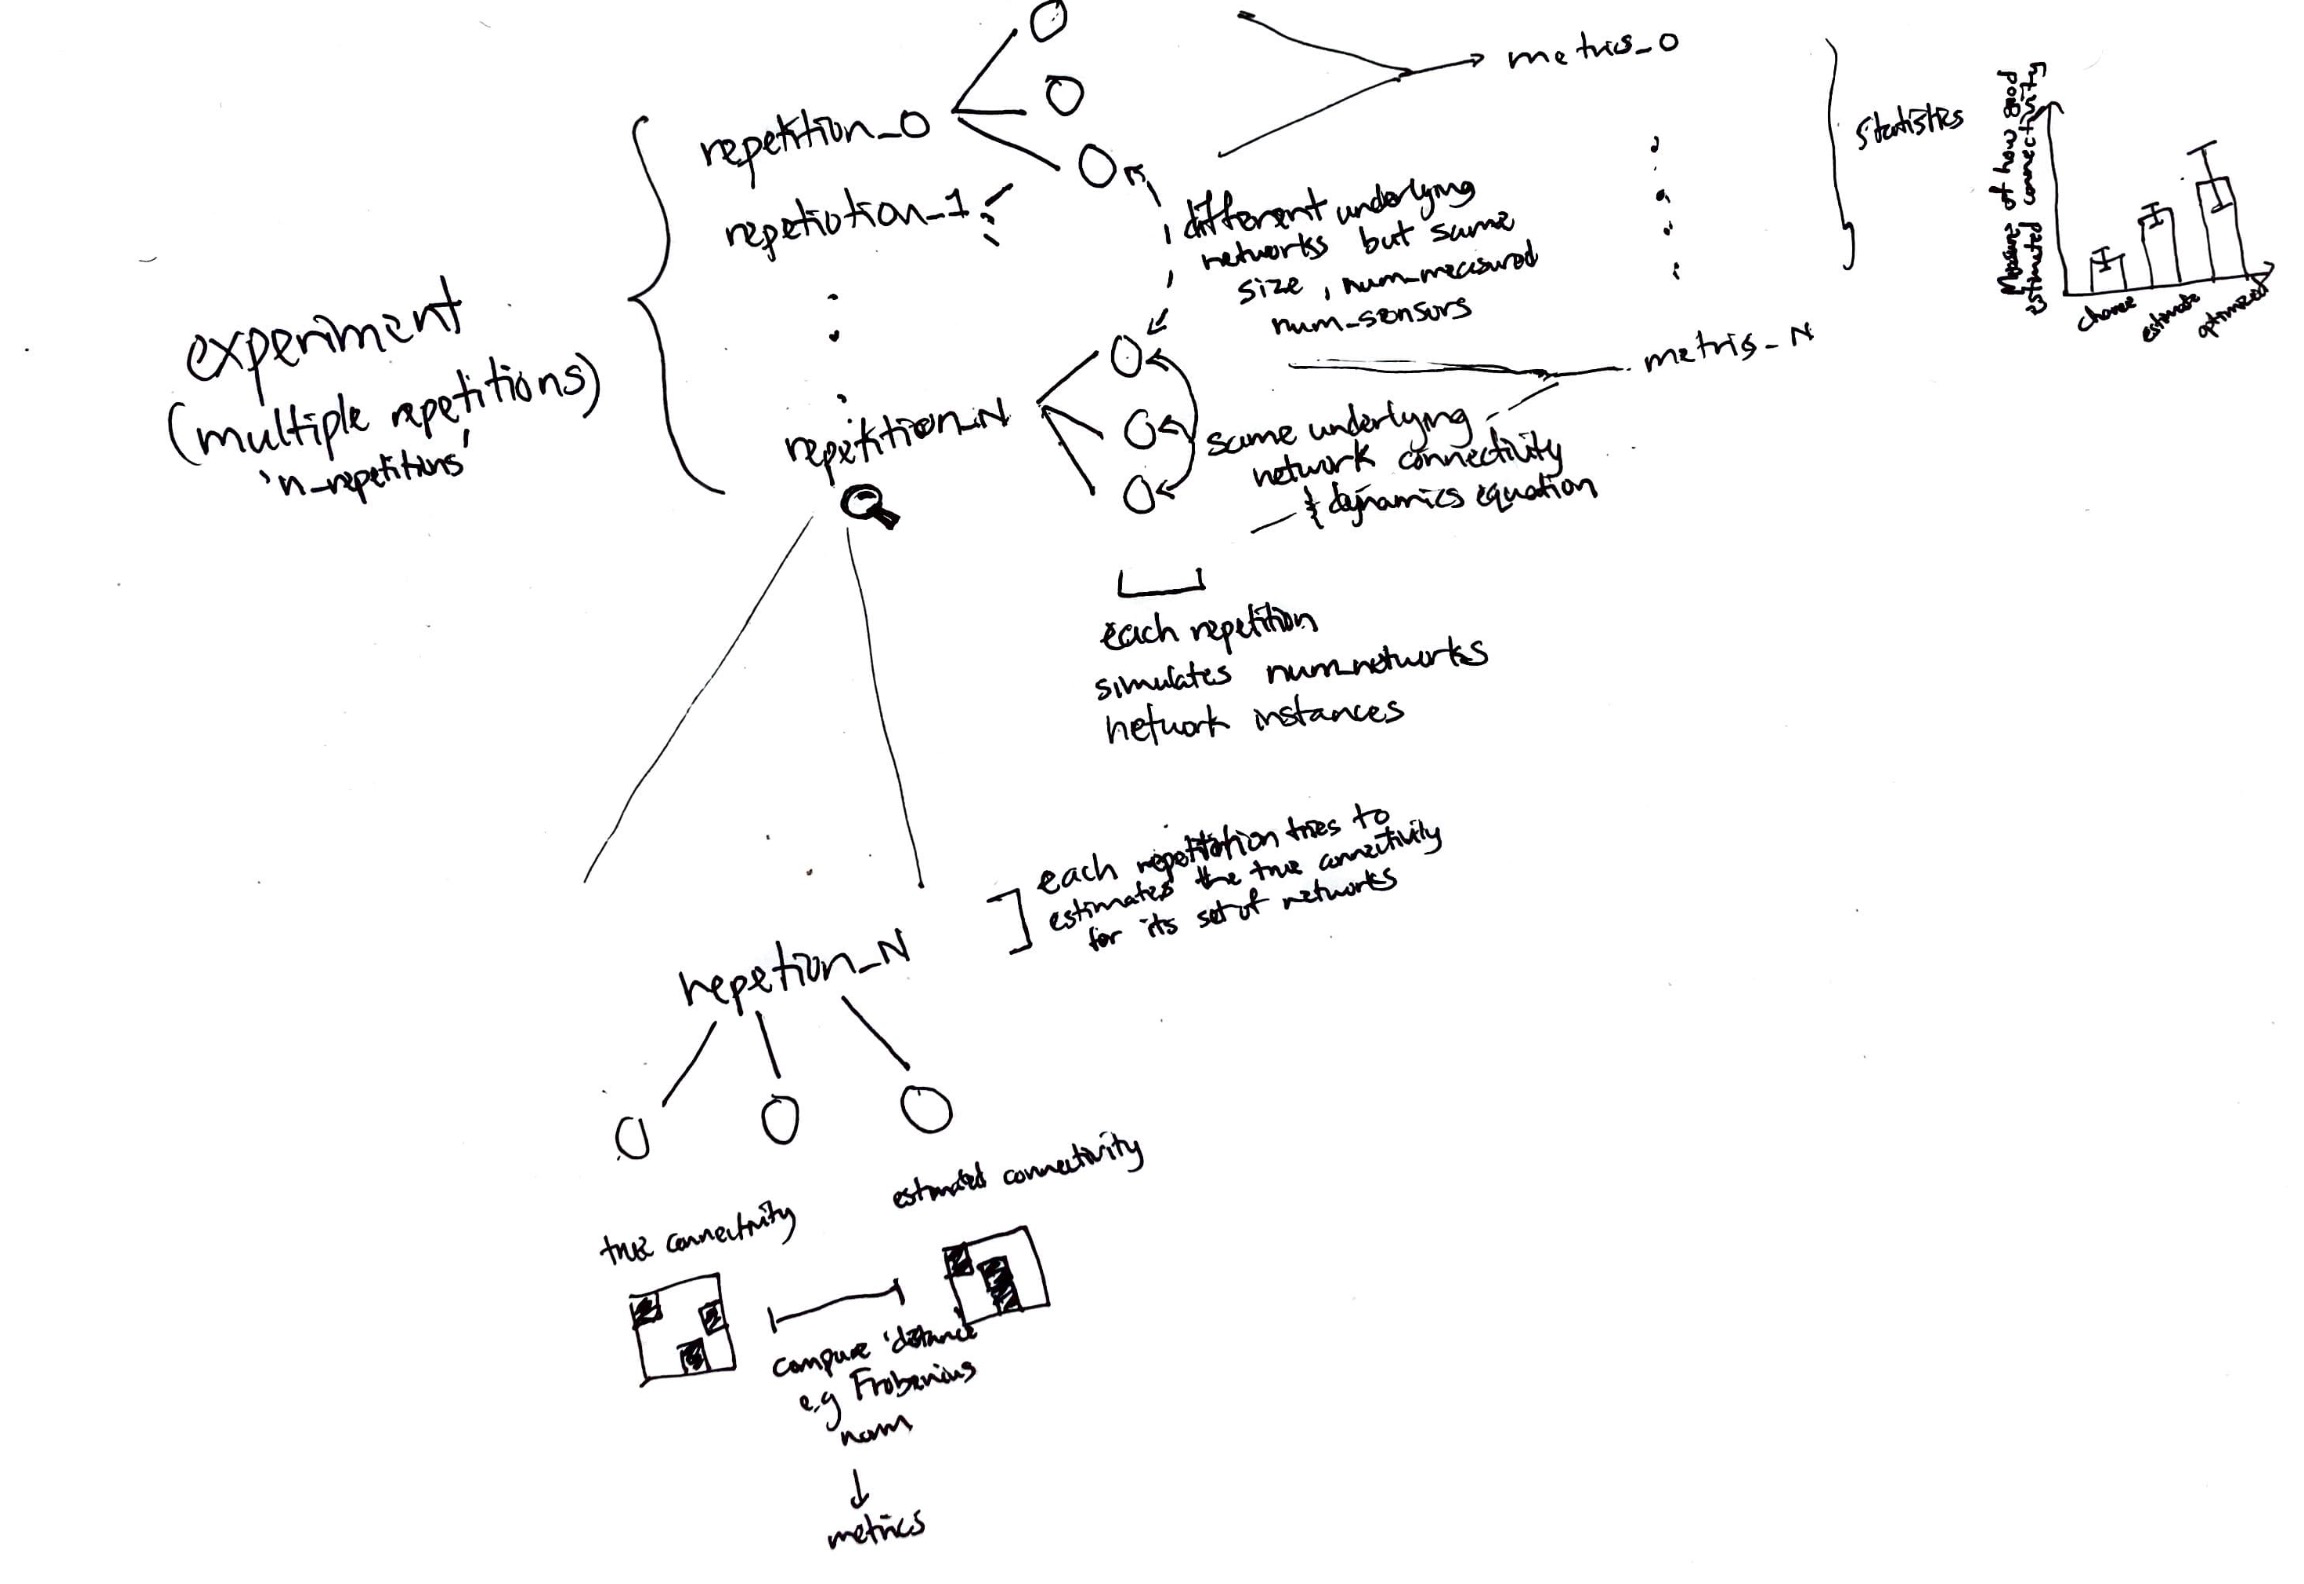

We initially estimate the connectivity weights by applying directly the mathematical formulation we derived in the markdown cells at the top of this notebook:
$$
\hat{\mathbf{W}}_{\text {approx }}=\hat{\boldsymbol{\Sigma}}_{\Delta t x}\left(\hat{\boldsymbol{\Sigma}_x}\right)^{-1}
$$

The code that implements this is `estimate_connectivity_weights`.

---


An intriguing scientific question is whether the estimate of connectivity
is more accurate when we condition on subsets of nodes i.e do the same computation `approx_W = cov_dtx @ np.linalg.pinv(cov_x)` but on a submatrix.

- e.g. `approx_W_sensory = cov_dtx.filter(sensory_node_locs) @ inverse(cov_x.filter(sensory_node_locs))`

- Is that different/more accurate than `approx_W.filter(sensory_node_locs)`?

We hypothesize this could be the case because it's possible that the overall covariance matrix `cov_x` is ill-conditoned, whereas there may exist particular square submatrices of it that are well-conditioned.

e.g. Restricting weight estimation to either sensory neurons or effector neurons.
```python
typ = e # which node types to condition on (`s` for sensory or `e` for effector)
Adj = Adj[typ, :][:, typ] # DEBUG
true_W = true_W[typ, :][:, typ] # DEBUG
approx_W =  cov_dtx[typ, :][:, typ] @ np.linalg.pinv(cov_x[typ, :][:, typ])
oracle_W = (cov_dtx - cov_bx)[typ, :][:, typ] @ np.linalg.pinv(cov_phix[typ, :][:, typ])
```

---


What's strange is that if we compute the estimator of the `W` matrix given oracle knowledge of the input `b` and nonlinearity `phi`, $W_{\text{oracle}^1}$ , we get an answer that is is worse than the non-oracle approximation. Why? This is really confusing. Observations:
 - The oracle estimator is better when predicting just sensory nodes.
 - The full approximation is better when prediciting just effector nodes.
 - When predicting both, the outcome seems to be an average of these two effects.
 - So if there are more sensory nodes than effector nodes then the oracle will perform better, and vice versa.

`oracle_W = (cov_dtx - cov_bx) @ np.linalg.pinv(cov_phix)`

---

In [ ]:
# A helper function for computing the approximate weights using our formulation. Implemented with numpy.
# TODO: Can we make this faster by doing the matrix operations on GPU using torch?
def estimate_connectivity_weights(num_nodes, multinet_dataset):
    """
    Estimating the connectivity from data:
        (num_nodes, T) x (T, num_nodes) -> (num_nodes, num_nodes)

    Idea 1: Reduced dependence between spaced apart state samples.
    Idea 2: Filter for small values so that the linear approximation is valid.
    Idea 3: Restrict weight estimation to either sensory neurons or effector neurons.
    """
    assert multinet_dataset['network0']['connection_weights'].shape == (num_nodes, num_nodes), f"Verify that the provide networks have {num_nodes} nodes."

    # Initialize covariances
    total_mask = np.zeros((num_nodes, num_nodes))
    cov_x = np.zeros((num_nodes, num_nodes))
    cov_dtx = np.zeros((num_nodes, num_nodes))

    cov_phix = np.zeros((num_nodes, num_nodes)) # oracle
    cov_bx = np.zeros((num_nodes, num_nodes)) # oracle

    # true_W is the ground-truth weight matrix; Adj is the adjacency matrix; phi is the element-wise nonlinear function
    true_W = None
    Adj = None
    phi = None

    # Loop over each network instance
    # print(f"Extracting / accumulating data from each network instance ... \n")
    num_networks = len(multinet_dataset)
    for network_idx in range(num_networks):
        # Get the current network
        network = f"network{network_idx}"
        network_data = multinet_dataset[network]

        # Check that "connectome" is the same for all networks
        if true_W is None:
            true_W = network_data["connection_weights"]
            Adj = network_data["adjacency_matrix"]
            phi = network_data["nonlinearity"] # oracle

        else:
            true_W_ = network_data["connection_weights"]
            assert np.allclose(true_W, true_W_), "Inconsistent connection weights!"
            true_W = true_W_
            Adj_ = network_data["adjacency_matrix"]
            assert np.allclose(Adj, Adj_), "Inconsistent adjacency matrix!"
            Adj = Adj_
            phi_, n_ = network_data["nonlinearity"], np.random.rand(num_nodes)
            assert np.allclose(phi(n_), phi_(n_)), "Inconsistent nonlinear functions!"
            phi = phi_ # oracle

        # Compute matrices needed to estimate the connectivity matrix
        mask = network_data["measured_nodes_mask"].reshape(-1, 1)
        data = network_data["activity_data"]  # (num_samples, num_nodes)

        # Having the inputs requires an oracle (knowledge of the inputs and nonlinearity)
        inputs = network_data["total_input_matrix"]  # oracle
        B = inputs # (num_samples, num_nodes); unused

        # Used to perform the estimation
        X = data
        n = data.shape[0] - 1 # because we leave out first or last index when we slice below
        S = mask @ mask.T
        total_mask += S

        # Use all sampled time-points to compute the various covariance matrices
        cov_x += ((X[:-1].T @ X[:-1]) / n) * S
        cov_dtx += ((X[1:].T @ X[:-1]) / n) * S
        cov_phix +=  ((phi(X[:-1]).T @ X[:-1]) / n) * S # oracle
        cov_bx += ((B[:-1].T @ X[:-1]) / n) * S # oracle

    # Average covariance over samples of (node i, node j) pairs across networks
    num_never_obs = (
        np.diag(total_mask) < 1
    ).sum()  # number of distinct neurons never measured
    total_mask = np.clip(total_mask, a_min=1, a_max=None)  # avoids division by zero
    cov_x = np.divide(cov_x, total_mask)
    cov_dtx = np.divide(cov_dtx, total_mask)
    cov_phix = np.divide(cov_phix, total_mask) # oracle
    cov_bx = np.divide(cov_bx, total_mask) # oracle

    # Estimator of W matrix assuming no oracle
    print(f"\t\t\tSolving for estimated connectivity matrix ... \n")
    approx_W = cov_dtx @ np.linalg.pinv(cov_x)

    # Estimator of W using oracle knowledge of input and nonlinearity
    oracle_W = (cov_dtx - cov_bx) @ np.linalg.pinv(cov_phix)

    # Make a dictionary of things to return
    results_dict = dict(approx_W=approx_W, true_W=true_W, oracle_W=oracle_W,
                        cov_x=cov_x, cov_dtx=cov_dtx, Adj=Adj, phi=phi,
                        total_mask=total_mask, num_never_obs=num_never_obs)


    return results_dict

After getting the initial estimate, we derived an optimization that refines the initial guess using an original idea inspired by Granger causality.

**Novel idea related Granger Causality with directed graphs and temporal covariances**

**Granger causality** is a statistical notion of causality designed primarily for time-series data. In simple terms, one time series $X(t)$ *Granger-causes* another series $Y(t)$ if knowing the past values of $X$ (as well as the past of $Y$) helps you predict the future values of $Y$ *significantly better* than only knowing $Y$'s own past.  

Formally, you fit two predictive models for $Y$:
1. A “reduced” model using only $Y$'s own history.
2. A “full” model using both $Y$'s history **and** $X$'s history.

If the full model's predictions of $Y$ are statistically better (e.g., lower mean-square error) than the reduced model's predictions, we say **$X$ *Granger-causes* $Y$**. Note this is *not* absolute proof of causal influence in the lay sense—only that $X$ has additional predictive power about $Y$ beyond $Y$'s own past. The method is commonly used in econometrics, neuroscience, and other domains to probe *directional* relationships between signals.

---

_Our idea_ is a Granger test that involves covariances of the time series rather than the time series themselves.

**Test for temporal causality of directed edges using covariance matrices**

If two variables (i.e nodes) - let's call them $Y$ and $Z$ - have a causal connection (i.e directed edge) between them - let's say from $Y$ to $Z$, then the $\operatorname{cov}(Y_t, Z_{t+1}) > \operatorname{cov}(Y_t, Z_t)$. This is reminiscent of Granger causality and is probably closely related to it.

---

Conversely, if $Y$ and $Z$ are not directly connected in this way, then $\operatorname{cov}(Y_t, Z_t) > \operatorname{cov}(Y_t, Z_{t+1})$.

**NOTE:** We observe that this query fails to to make the right identification for an edge going into a sensory (i.e input) node. It is otherwise very good at identifying the *absence* of a directed edge. Thus, the query $\operatorname{cov}(Y_t, Z_t) > \operatorname{cov}(Y_t, Z_{t+1})$ identifies correctly when there is *not* an edge from node $Y$ to node $Z$ (i.e true positive). This query should be used if we can tolerate false negatives (i.e suggesting the presence of an edge when there isn't one) but not false positives (i.e suggesting the absence of an edge when there is one).

**QUESTION:** Does the magnitude of the difference $|\operatorname{cov}(Y_t, Z_{t+1}) - \operatorname{cov}(Y_t, Z_t)|$ reflect the (relative) strength of the directed edge?

---

Below is an example **projected gradient** (PG)-style solver:

1. **Objective**: minimize $\|A - A_{\text{init}}\|_F$.  
2. **Zero Positions**: for all $(i, j)$ where $\Sigma_x[i,j] > \Sigma_{dtx}[i,j]$, enforce $(A B)[i, j] = 0$.  Also zero the diagonal of $(A B)$.  
3. **Nonnegative Constraint**: $(A B)[i,j] \ge 0$.

This is a bit more complex than simply projecting $A$ itself to have zeros on its diagonal. Instead, we are projecting the product $W = A\,B$. So the main steps become:

- **Compute** the gradient wrt $A$.
- **Update** $A$ by gradient descent.
- **Project** $\bigl(A\,B\bigr)$ so that it satisfies your constraints:
  - zero diagonal $\bigl(A\,B\bigr)_{ii} = 0$.
  - zero at $\bigl(A\,B\bigr)[i,j]$ for $\Sigma_x[i,j] > \Sigma_{dtx}[i,j]$.
  - nonnegative on all entries $\bigl(A\,B\bigr)_{i,j} \ge 0$.

Because we need to “project” changes in $W = A\,B$ back into $A$, the code will do a small least-squares step to find the \(A\) closest (in Frobenius norm) to the updated gradient step, subject to the constraints on $W$. In other words:

1. We do a gradient step: $\tilde A \leftarrow A - \eta\,(A - A_{\text{init}})$.  
2. We try to find the “closest” matrix \(A_{\mathrm{new}}\) (in the Frobenius sense) so that \((A_{\mathrm{new}}\,B)\) meets your constraints.  
3. The matrix problem
   $$
   \min_{A_{\mathrm{new}}} \|A_{\mathrm{new}} - \tilde A\|_F^2 \quad \text{subject to}\quad (A_{\mathrm{new}} B)[i,j]\text{ satisfies the zero / nonnegative constraints}.
   $$
   is a (large) linear least-squares with equality and inequality constraints on the product $A_{\mathrm{new}}\,B$. We can solve it iteratively or with a small convex solver.  

Below is a code snippet that does an **iterative approach** to approximate that projection.  For large matrices, it still may not be super-fast, but at least it avoids the overhead of a big MILP or second-order solver.  It uses a repeated loop of:

- Re-initialize $W = \tilde A\,B$.
- Enforce the constraints on $W$: set forbidden entries to 0, clamp negative to 0, zero its diagonal.  
- Solve a small least-squares to find $A_{\mathrm{new}}\approx\tilde A$ that reproduces the newly clamped $W$. (Because $W = A\,B\implies A = W\,B^{\dagger}$ in least-squares sense.)

**Warning**: This is still *heuristic* and might not converge super-fast, but it's likely to be a big improvement over a raw CVX approach for large $n$.
You can tune how many sub-iterations of the “project $W$ $\to$ back-solve for $A$” step you do each gradient iteration.  Because $\Sigma_x$ might be invertible or near-invertible, it might be simpler to re-invert it once.  Also, keep in mind that the diagonal-zero/overlap constraints are on $W$, not necessarily on $A$ itself.

---

In [ ]:
#@title Optimization using simpler projected gradient approach instead of CVXPY. Implemented using numpy.
def clamp_W_constraints(W, mask_zero_positions, non_negative_weights=True, zero_diagonal=True):
    """
    - Zero out W[i,j] for any (i,j) in mask_zero_positions
    - If zero_diagonal=True, also sets diag(W)=0
    - Then clamp any negative entries to 0
    """
    if zero_diagonal:
        np.fill_diagonal(W, 0.0)
    # zero out positions (i,j) in mask
    for (i,j) in mask_zero_positions:
        W[i,j] = 0.0
    if non_negative_weights:
        # clamp negatives
        W = np.maximum(W, 0.0)
    return W

def least_squares_backsolve(W, B, alpha=1e-6):
    """
    Solve for A_new that approximates W = A_new @ B in least-squares sense.
    i.e. we want A_new = W * pinv(B), but pinv(B) might be large.

    We do A_new = W * B^T (B B^T + alpha I)^{-1}, a typical ridge-lsq solution
    because W is (n x n) and B is (n x n).

    This is just a direct approach for B invertible or nearly invertible.
    If B is invertible, then A_new = W @ inv(B).
    If B is not well-conditioned, we do ridge (alpha).
    """
    n = B.shape[0]
    # form (B B^T + alpha I) inverse
    BBt = B @ B.T
    for i in range(n):
        BBt[i,i] += alpha  # ridge
    BBt_inv = np.linalg.inv(BBt)

    # A_new = W @ B^T @ BBt_inv
    A_new = W.dot(B.T).dot(BBt_inv)
    return A_new

def projected_gradient_causal(
    cov_x, cov_dtx,
    non_negative_weights=True,
    zero_diagonal=True,
    steps=200,
    lr=1e-3,
    subiters=3
):
    """
    Minimizes Frobenius norm ||A - A_init||^2 subject to:
       (A B)[i,i] = 0 if zero_diagonal
       (A B)[i,j] = 0 if cov_x[i,j] > cov_dtx[i,j]
       (A B)[i,j] >= 0 if non_negative_weights
    using gradient steps + repeated projection in W-space.

    Args:
      cov_x: used for B = pinv(cov_x)
      cov_dtx: A_init in your notation
      steps: number of outer PGD iterations
      subiters: how many times we re-project W and solve for A in each outer iteration
    """
    # we could optimize either cov_x or cov_dtx; here we do cov_dtx
    A_init = cov_dtx.copy()
    n = A_init.shape[0]
    # pseudo-inverse
    B = np.linalg.pinv(cov_x)

    # we build a list of mask positions for zeros:
    # diagonal -> (i,i)
    # also (i,j) for cov_x[i,j] > cov_dtx[i,j]
    zero_positions = []
    if zero_diagonal:
        zero_positions.extend((i, i) for i in range(n))
    idx = np.argwhere(cov_x > cov_dtx)
    zero_positions.extend((int(i),int(j)) for (i,j) in idx)

    # init A
    A = A_init.copy()

    for it in range(steps):
        # gradient step
        grad = (A - A_init)
        A -= lr * grad

        # repeated sub-iteration to enforce constraints in W = A*B
        for _ in range(subiters):
            W = A @ B
            # clamp & zero out positions
            W = clamp_W_constraints(W, zero_positions,
                                    non_negative_weights=non_negative_weights,
                                    zero_diagonal=zero_diagonal)
            # back-solve for A that approximates that W
            A = least_squares_backsolve(W, B)

    # final
    W_optimized = A @ B
    A_optimized = A
    return A_optimized, W_optimized

def optimize_projected_gradient_causal(
    cov_x, cov_dtx,
    non_negative_weights=True,
    zero_diagonal=True,
    steps=200,
    lr=1e-3,
    subiters=3
):
    """
    Usage:
    ```python
      A_star, W_star = optimize_projected_gradient_causal(
          cov_x, cov_dtx,
          non_negative_weights=True,
          zero_diagonal=True,
          steps=500,
          lr=1e-3,
          subiters=2
      )
    ```
    """
    print(f"\t\t\t\tOptimizing estimate weights with projected gradient (causal constraints) ...\n")
    A_optimized, W_optimized = projected_gradient_causal(
        cov_x, cov_dtx,
        non_negative_weights=non_negative_weights,
        zero_diagonal=zero_diagonal,
        steps=steps, lr=lr, subiters=subiters
    )
    return A_optimized, W_optimized


In [ ]:
# Function for one repetition of an experiment
def one_repetition(
    repetition_idx,
    random_seed,
    num_networks,
    max_timesteps,
    num_nodes,
    num_cpgs,
    num_measured,
    num_sensors,
    fixed_sensors,
    stim_gain,
    nonlinearity,
    non_negative_weights,
    force_stable,
):
    """
    One repetition of an experiment.
    This does a lot of the work like computing the estimated weight matrices
    using our special formulation we devised based on covariance matrices.
    """
    # Set random seeds for reproducibility
    torch.manual_seed(random_seed + repetition_idx)
    np.random.seed(random_seed + repetition_idx)

    # NOTE: Each repetition is a distinct network and this network is
    #       reproduced `num_networks` times for each repetition index.

    # Create a dataset of multiple instance networks
    # print(f"Running repetition {repetition_idx} of experiment... \n")
    dataset = create_multinetwork_dataset(
        num_networks,
        max_timesteps,
        num_nodes,
        num_cpgs,
        num_measured,
        num_sensors,
        fixed_sensors,
        stim_gain,
        nonlinearity,
        non_negative_weights,
        force_stable,
    )

    # Perform computation based on our math derivation for connectivity weights
    estim_results = estimate_connectivity_weights(num_nodes, dataset)
    approx_W, true_W, oracle_W = estim_results['approx_W'], estim_results['true_W'], estim_results['oracle_W'] # initial estimate
    Adj, phi = estim_results['Adj'], estim_results['phi']
    total_mask, num_never_obs = estim_results['total_mask'], estim_results['num_never_obs']
    cov_x, cov_dtx = estim_results['cov_x'], estim_results['cov_dtx']

    # Using Granger-causality inspired hypothesis to find an optimized estimate
    optim_A, optim_W = optimize_projected_gradient_causal(cov_x, cov_dtx, non_negative_weights) # optimized estimate

    # Sample weights from same distribution as true connectivity
    eps = np.finfo(float).eps
    # see that code in `random_network` topology is same as this:
    eps = np.finfo(float).eps
    if non_negative_weights:
        # ~Unif(0,1) if non-negative
        sample_W = eps + np.random.rand(*true_W.shape) # matching distribution
    else:
        # ~Unif(-1,1) if non-negative
        sample_W = 2 * (eps + np.random.rand(*true_W.shape) - 0.5)
    # If we also knew what the adjacency matrix was
    adj_sample_W = Adj * sample_W # + matching connectedness
    # If we also knew of any constraints on the stability/spectral norm
    spec_adj_sample_W = adjust_spectral_radius(adj_sample_W, target_radius=calculate_spectral_radius(true_W)) # matching stability

    # Calculate the estimate and prior (baseline) distances from ground-truth
    # NOTE: We normalize distances by the network size
    ESTIM_DIST = np.linalg.norm(true_W - approx_W, ord="fro") / num_nodes
    distances = {
        "chance_distance": np.linalg.norm(true_W - sample_W, ord="fro") / num_nodes,
        "adjacency_distance": np.linalg.norm(true_W - adj_sample_W, ord="fro") / num_nodes,
        "spectral_distance": np.linalg.norm(true_W - spec_adj_sample_W, ord="fro") / num_nodes,
        "estimate_distance": ESTIM_DIST,
        "optimized_distance": np.linalg.norm(true_W - optim_W, ord="fro") / num_nodes,
    }

    print(f"Logging results to Weights & Biases ... \n")
    global BEST_DIST
    if ESTIM_DIST < BEST_DIST:
        BEST_DIST = ESTIM_DIST
        network_idx = np.random.choice(num_networks)
        network_data = dataset[f'network{network_idx}']
        node_to_index = network_data["node_to_index"]
        # Generate Heatmaps
        ticklabels = [
            f"$n{s.strip('node')}$"
            for s in sorted(node_to_index, key=lambda k: node_to_index[k])
        ]
        heatmap_png = generate_heatmaps(
            true_W, approx_W, optim_W, total_mask, repetition_idx, ticklabels
        )

        # Plot network dynamics in reduced dimensions
        obs = np.argwhere(network_data["measured_nodes_mask"]).squeeze().tolist()
        X = network_data["activity_data"][:, obs]  # (T, num_measured)
        pca_png = f"pca_rep_{repetition_idx}_net_{network_idx}.png"
        generate_pca_plot(X, pca_png)

        # Visualization of the last network instance
        network_png = f"network_rep_{repetition_idx}_net_{network_idx}.png"
        if num_nodes < 100:  # only draw if small enough network
            # NOTE: Vizualize the network with the CPG node embedded
            visualize_network(
                networkx_graph=network_data["networkx_graph"],
                measured_nodes_mask=network_data["measured_nodes_mask"],
                sensor_nodes_mask=network_data["sensor_nodes_mask"],
                cpg_nodes_mask=network_data["cpg_nodes_mask"],
                show_fig=False,
                save_png=True,
                png_name=network_png,
            ) # networks from the same repetition have the same topology
        # Images made from experiment
        images = {"heatmap": heatmap_png, "network": network_png, 'pca': pca_png}
    else:
        images = dict()

    # TODO: Figure out what else you want to save from a repetition
    # e.g. full multinet dataset; weight estimation results; optimized weights; various chance weights
    # We can try insering thouse as new fields in the multinetwork `dataset` and then dumping to json or pickle.
    return distances, images

In [ ]:
# Main experiment function
def run_experiment(
    random_seed=42,
    num_repetitions=17,
    num_networks=1,
    max_timesteps=1000,
    num_nodes=3,
    num_cpgs=None,
    num_measured=None,
    num_sensors=None,
    fixed_sensors=False,
    stim_gain=1.0,
    nonlinearity="tanh",
    non_negative_weights=True,
    force_stable=True,
):
    """
    Run the experiment with specified parameters for multiple repetitions and
    return the results in the form of 95% confidence intervals around the
    various distances we calculate. A single experiment involves creating a dataset of
    `num_networks` instances of with the exact same underlying connectivity and
    parameters controlling the dynamics. Each instance can be thought of as a
    realization/unrolling of the dynamics on a fixed graph from different initial
    conditions. We may measure and stimulate (if `fixed_sensors` is False) a different
    set of nodes in different instances, however. Hence multiple repetitions are
    used to quantify the impact of variations in observability and stimulation.

    Parameters:
    - random_seed: random seed to ensure experiment reproducibility.
    - num_repetitions: number of repetitions of the experiment.

    Returns:
    - distance_df: DataFrame containing distance metrics for each repetition.
    - CI_df: DataFrame containing 95% confidence intervals for each distance metric.
    - figures_list: List of file paths to images of plots made from the experiment.
    """
    # Basic experiment assertion check
    assert num_repetitions > 1, "Need more than 1 repetition for a valid experiment"

    # Default values for num_cpgs, num_measured and num_sensors if not provided
    # CPGs
    if num_cpgs < 0: # -999
        num_cpgs = 1 # have at least one CPG node
    elif num_cpgs == 0: # 0
        num_cpgs = max(1, np.ceil(1 / 6 * num_nodes).astype(int))
    elif num_cpgs > num_nodes: # 999
        num_cpgs = np.ceil(1 / 3 * num_nodes).astype(int)

    # measured/observed
    if num_measured < 0:  # -999
        num_measured = max(2, np.ceil(1 / 3 * num_nodes).astype(int))  # need at least two nodes to compute covariance
    elif num_measured == 0:  # 0
        num_measured = np.ceil(2 / 3 * num_nodes).astype(int)
    elif num_measured > num_nodes: # 999
        num_measured = num_nodes

    # sensors/stimulated
    if num_sensors < 0: # -999
        num_sensors = 1 # we stimulate at least one node
    elif num_sensors == 0: # 0
        num_sensors = max(1, np.ceil(1 / 6 * num_nodes).astype(int))
    elif num_sensors > num_nodes: # 999
        num_sensors = np.ceil(1 / 3 * num_nodes).astype(int)

    # Ensure nonlinearity is parsed as a callable
    if isinstance(nonlinearity, str):
        try:
            # Try to evaluate the nonlinearity as a direct callable
            nonlinear_func = eval(nonlinearity)
        except NameError:
            try:
                # Try to evaluate the nonlinearity as a numpy function
                nonlinear_func = eval(f"np.{nonlinearity}")
            except Exception as e:
                # Raise a more informative error if neither works
                raise ValueError(
                    f"Invalid nonlinearity function name: {nonlinearity}"
                ) from e

    # Will return config with updated values
    config = dict(
        random_seed=random_seed,
        num_repetitions=num_repetitions,
        num_networks=num_networks,
        max_timesteps=max_timesteps,
        num_nodes=num_nodes,
        num_cpgs=num_cpgs,
        num_measured=num_measured,
        num_sensors=num_sensors,
        fixed_sensors=fixed_sensors,
        stim_gain=stim_gain,
        nonlinearity=nonlinearity,
        non_negative_weights=non_negative_weights,
        force_stable=force_stable,
    )

    # Initialize distance variable that updates across jobs
    global BEST_DIST
    BEST_DIST = float("inf")

    # Initialize lists to store results
    distance_metrics = []
    figures_list = []

    # Parallel execution of experimental repetitions
    ### using JOBLIB
    results = joblib.Parallel(n_jobs=-2, verbose=1)( # n_jobs=1 is just a for loop
        joblib.delayed(one_repetition)(
            repetition_idx,
            random_seed,
            num_networks,
            max_timesteps,
            num_nodes,
            num_cpgs,
            num_measured,
            num_sensors,
            fixed_sensors,
            stim_gain,
            nonlinear_func,
            non_negative_weights,
            force_stable,
        )
        for repetition_idx in range(num_repetitions)
    )

    # Unpack results from parallel execution
    for distances, images in results:
        distance_metrics.append(distances)
        if images is not None:
            if images.get('heatmap') and os.path.exists(images["heatmap"]):
                figures_list.append(images["heatmap"])
            if images.get('network') and os.path.exists(images["network"]):
                figures_list.append(images["network"])
            if images.get('pca') and os.path.exists(images["pca"]):
                figures_list.append(images["pca"])


    # Convert distance metrics to a DataFrame
    distance_df = pd.DataFrame(distance_metrics)
    distance_df.index.name = "repetition"
    desired_order = [
        "chance_distance",
        "adjacency_distance",
        "spectral_distance",
        "estimate_distance",
        "optimized_distance",
    ]
    distance_df = distance_df[desired_order]  # reorder columns

    # Vectorized bootstrap for confidence intervals of each distance column
    data = distance_df.to_numpy()
    res = bootstrap((data,), np.median, axis=0, confidence_level=0.95, n_resamples=1000)

    # Extract lower and upper confidence intervals for each column
    ci_l, ci_u = res.confidence_interval
    CIs = {
        distance_df.columns[i].split("_")[0] + "_CI": (ci_l[i], ci_u[i])
        for i in range(len(distance_df.columns))
    }
    CI_df = pd.DataFrame(CIs, index=["low", "high"])

    # Create bar plot summarizing distances
    bar_graph_summary_png = generate_bar_graph(distance_df, CI_df)
    figures_list.append(bar_graph_summary_png)

    # TODO: Figure what else that you want to save from an experiment
    return distance_df, CI_df, figures_list, config

In [ ]:
# Define the experiment run function with WandB integration
def run_experiment_with_wandb(config=None):
    with wandb.init(config=config):

        # Run the experiment
        distance_df, CI_df, figures_list, config = run_experiment(**wandb.config)
        wandb.config = config

        # Calculate a score to determine the best run
        score = (
            CI_df["spectral_CI"].low - CI_df["estimate_CI"].high
        )  # maximize non-overlap of confidence intervals

        # Prepare images to log and delete local copies
        images = []  # create list of images
        for impath in figures_list:
            images.append(
                wandb.Image(plt.imread(impath), caption=impath)
            )  # add to list
            os.remove(impath)  # delete locally

        # Log the distance dataframe as a table
        wandb.log(
            {"weight_distances_table": wandb.Table(dataframe=distance_df)}, commit=False
        )

        # Log the confidence intervals dataframe as a table
        wandb.log(
            {"confidence_intervals_table": wandb.Table(dataframe=CI_df)}, commit=False
        )

        # Log the median distances as metrics
        wandb.log(
            {
                "median_" + col: np.median(CI_df[col.split("_")[0] + "_CI"])
                for col in distance_df
            },
            commit=False,
        )

        # Log the score
        wandb.log({"score": score}, commit=False)

        # Log the images
        wandb.log({f"images": images})  # comm=True by default

    return None

**Draft methods for *C elegans* stimulation for connectivity estimation paper**

For the purposes of our work, connecting it to *C elegans* neuroscience:

Note "unmeasured" means the same thing as "not recorded".  

unlabeled neuron  == unmeasured node

Future work may wish to consider the problem of label assignment to recorded but unlabeled neurons.

Each instance of the network is to be considered as a worm.

worm == network instance

Within each network, some nodes are central pattern generators nodes (CPGs). The CPG is implemented as an unmodeled autonomous but state-modulated input to the CPG nodes using a random neural network.

cpg node == intrinsic dynamics

We call the neurons where stimulation is applied the sensors.

sensor node == stimulated neuron

---

Our simulation set up is as follows. For a given network size, we generate a random connectivity that meets certain criteria described next but that is held fixed across all worms.

We simulate all networks for a maximum of 900 timesteps (abritrary but sufficient).

Each repetetion is a simulation of a different underlying network but with the parameters the same. We perform an experiment with 10 repetitions.

num repetitions == num distinct net topologies

The connectivity is chosen by sampling the minimum connectivity needed to connect all nodes in the graph, sampling non-negative weights from [0, 1] and normalizing the network so that it has spectral radius of 1.

We also standardize the activity time series of each node independently.

---

**Protocol**

- Simulate networks of sizes 12, 60 and 150.

- At each network size, simulate a pool of 50, 100 or 200 instances.

- At each network size, we measure either 1/3, 2/3 or all of the nodes.

- At each network size, we stimulate either 1/6, 1/3 or exactly 1 of the nodes.

- At each network size, we make CPGs either 1/6, 1/3 or exactly 1 of the nodes.

- At each network size, we use either 0, 0.5 or 1 as the stimulation gain.
That's a total of $3^5 = 243$ combinations.

In [ ]:
# @title Example of running one experiment
# @markdown There are 24 combinations we want to sweep through.
# @markdown See description in markdown cell above and `wandb` experiment in code cell below.

np.random.seed(27)
torch.manual_seed(27)

# Define the run configuration
config = dict(
    random_seed=27,
    num_repetitions=17,
    num_networks=50,  # [50, 100]
    max_timesteps=900,
    num_nodes=12,  # [12, 60, 150]
    num_cpgs=-999,  # [-float('inf'), 0, float('inf')] == [1, 1/6, 1/3]
    num_measured=-999,  # [-float('inf'), 0, float('inf')] == [1/3, 2/3, all]
    num_sensors=None,  # [-float('inf'), 0, float('inf')] == [1, 1/6, 1/3]
    fixed_sensors=False,
    stim_gain=1.0,
    nonlinearity="tanh",
    non_negative_weights=True,
    force_stable=True,
)

# Run experiment
distance_df, CI_df, figures_list, config = run_experiment(**config)

# Display results
print(distance_df.head(), end="\n\n")
print(CI_df.head(), end="\n\n")
print("Figures:", figures_list, end="\n\n")

# Initialize wandb run
# num_networks-50_num_nodes-12_num_cpgs-17%_num_measured-66%_num_sensors-33%_stim_gain-1
run_name = f"nets-{config['num_networks']}_nodes-{config['num_nodes']}_cpgs-{config['num_cpgs']}_meas-{config['num_measured']}_sense-{config['num_sensors']}_stim-{config['stim_gain']}"
wandb.init(entity="qsimeon", project="network_recovery_run", config=config, name=run_name, save_code=False)

# Prepare images to log and delete local copies
images = []  # create list of images
for impath in figures_list:
    images.append(wandb.Image(plt.imread(impath), caption=impath))  # DEBUG
    os.remove(impath)  # delete locally
wandb.log({"images": images})
wandb.finish()

In [ ]:
# @title Example of running multiple experiments with wandb

np.random.seed(42)
torch.manual_seed(42)

# Define the sweep configuration
sweep_config = {
    "method": "grid",  # Use grid or random search
    "metric": {"name": "score", "goal": "maximize"},  # Optimize the score
    "parameters": {
        # things to fix
        "random_seed": {"value": 42},
        "num_repetitions": {"value": 17},  # n>2
        "max_timesteps": {"value": 900},
        "fixed_sensors": {"value": False},
        "stim_gain": {"value": 1.0},
        "nonlinearity": {"value": "tanh"},  # odd function & 1-Lipschitz & bounded
        "non_negative_weights": {"value": True},
        "force_stable": {"value": True},
        # things to vary
        # "stim_gain": {"values": [0.0, 0.5, 1.0]},
        "num_networks": {"values": [50, 100, 200]},
        "num_nodes": {"values": [12, 60, 150]},
        "num_cpgs": {"values": [-999, 0, 999]},  # [1, num_nodes]
        "num_measured": {"values": [-999, 0, 999]},  # [2, num_nodes]
        "num_sensors": {"values": [-999, 0, 999]},  # [0, num_nodes]
    },
}


# # Initialize and run the sweep
# sweep_id = wandb.sweep(
#     sweep_config, entity="qsimeon", project="network_recovery_experiment"
# )
# wandb.agent(sweep_id, function=run_experiment_with_wandb, count=243)
# # NOTE `count` is the number of sweep configurations to try i.e. the number of experiments to run
# wandb.finish()

##########################################

# Continue from a previous sweep
wandb.agent(sweep_id="47okp9io", function=run_experiment_with_wandb, count=100, entity="qsimeon", project="network_recovery_experiment")
# NOTE `count` is the number of sweep configurations to try i.e. the number of experiments to run
wandb.finish()

wandb: Ctrl + C detected. Stopping sweep.


[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  1.0min
Traceback (most recent call last):


---

### Code below is for making sure the parts work.

In [ ]:
np.random.seed(27)
torch.manual_seed(27)

# Initialize parameters
num_networks = 50
max_timesteps = 900
num_nodes = 12
num_cpgs = np.ceil(1/3 * num_nodes).astype(int)  # 33% of nodes are CPGs
num_measured = np.ceil(2/3 * num_nodes).astype(int) # 66% of nodes are measured
num_sensors = np.ceil(1/3 * num_nodes).astype(int)  # 33% of nodes are sensors
fixed_sensors = False
stim_gain = 0.0 #2**(-0.5) # stimulation
nonlinearity = (
    np.tanh
)  # nonlinear activation function (odd-function & 1-Lipschitz & bounded)
non_negative_weights = True
force_stable = True

print(
    f"(num_nodes, num_cpgs, num_measured, num_sensors): {num_nodes, num_cpgs, num_measured, num_sensors}\n"
)  # DEBUG
print("~" * 60, end="\n\n")

######################################################################################################

# Create a dataset of multiple instance networks
dataset = create_multinetwork_dataset(
    num_networks,
    max_timesteps,
    num_nodes,
    num_cpgs,
    num_measured,
    num_sensors,
    fixed_sensors,
    stim_gain,
    nonlinearity,
    non_negative_weights,
    force_stable,
)

######################################################################################################

(num_nodes, num_cpgs, num_measured, num_sensors): (12, np.int64(4), np.int64(8), np.int64(4))

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~



[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    2.4s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    2.6s finished


In [ ]:
### DEBUG ###

# Inspect broadly all of the network instances
count = 0
for network_idx in range(num_networks - 1, -1, -1):
    network = f"network{network_idx}"
    obs = (
        np.argwhere(dataset[network]["measured_nodes_mask"]).squeeze().tolist()
    )  # (num_measured,)
    obs = [obs] if isinstance(obs, int) else obs
    sen = (
        np.argwhere(dataset[network]["sensor_nodes_mask"]).squeeze().tolist()
    )  # (num_sensors,)
    sen = [sen] if isinstance(sen, int) else sen
    cpg = (
        np.argwhere(dataset[network]["cpg_nodes_mask"]).squeeze().tolist()
    )  # (num_cpgs,)
    cpg = [cpg] if isinstance(cpg, int) else cpg
    print(network)
    print(f"\t measured nodes: {[f'node{_}' for _ in obs]}")
    print(f"\t sensory nodes: {[f'node{_}' for _ in sen]}")
    print(f"\t cpg nodes: {[f'node{_}' for _ in cpg]}")
    count += 1
    if count > 5:
        break
print("~" * 60, end="\n\n")

### DEBUG ###


network49
	 measured nodes: ['node2', 'node3', 'node5', 'node6', 'node7', 'node8', 'node9', 'node11']
	 sensory nodes: ['node0', 'node3', 'node7', 'node9']
	 cpg nodes: ['node0', 'node1', 'node2', 'node3']
network48
	 measured nodes: ['node1', 'node2', 'node3', 'node5', 'node8', 'node9', 'node10', 'node11']
	 sensory nodes: ['node3', 'node6', 'node7', 'node8']
	 cpg nodes: ['node0', 'node1', 'node2', 'node3']
network47
	 measured nodes: ['node2', 'node4', 'node5', 'node6', 'node7', 'node8', 'node10', 'node11']
	 sensory nodes: ['node0', 'node6', 'node7', 'node11']
	 cpg nodes: ['node0', 'node1', 'node2', 'node3']
network46
	 measured nodes: ['node0', 'node2', 'node5', 'node6', 'node7', 'node8', 'node9', 'node11']
	 sensory nodes: ['node2', 'node5', 'node6', 'node10']
	 cpg nodes: ['node0', 'node1', 'node2', 'node3']
network45
	 measured nodes: ['node0', 'node1', 'node2', 'node3', 'node4', 'node6', 'node9', 'node10']
	 sensory nodes: ['node1', 'node5', 'node8', 'node9']
	 cpg nodes: ['n

network id: network0

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

input matrix shape: (900, 12)



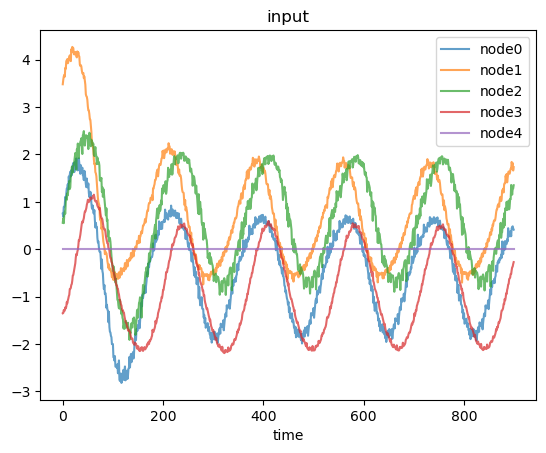


measurement data shape: (900, 8)



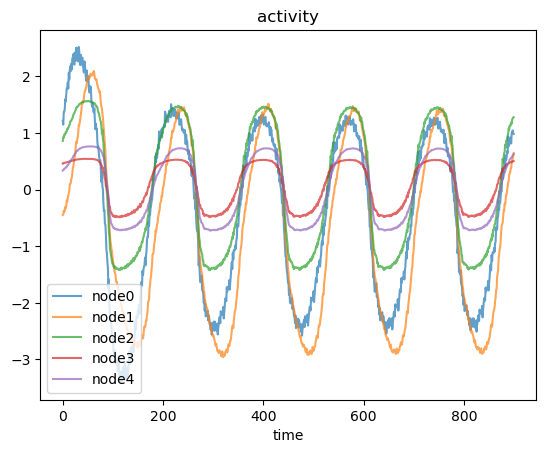

In [ ]:
# Investigate data from one of the network instances
network_idx = 0
network = f"network{network_idx}"
print(f"network id: {network}\n")
# print(dataset[network]["extra_info"], end="\n\n") # DEBUG
print("~" * 60, end="\n\n")

sen = dataset[network]["sensor_nodes_mask"]  # (num_nodes,)
b = dataset[network]["total_input_matrix"]  # (T, num_nodes)
print(f"input matrix shape: {b.shape}\n")
plt.plot(b[:, :5], label=[f"node{_}" for _ in range(5)], alpha=0.7)
plt.legend()
plt.xlabel("time")
plt.title("input")
plt.show()
print()

obs = np.argwhere(dataset[network]["measured_nodes_mask"]).squeeze().tolist()
X = dataset[network]["activity_data"][:, obs]  # (T, num_measured)
print(f"measurement data shape: {X.shape}\n")
plt.plot(X[:, :5], label=[f"node{_}" for _ in range(5)], alpha=0.7)
plt.legend()
plt.xlabel("time")
plt.title("activity")
plt.show()
print()

##################################################################################

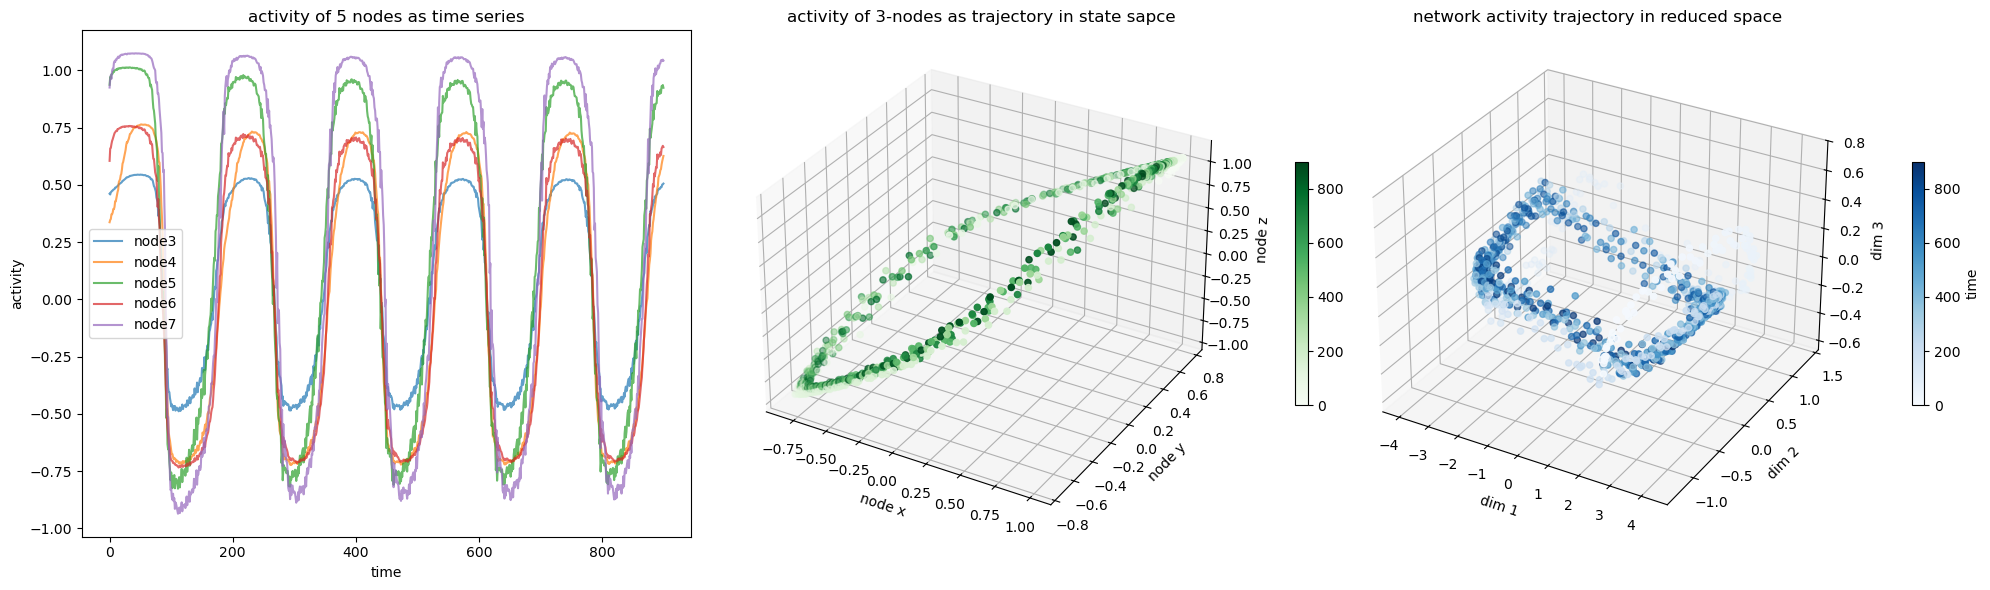

In [ ]:
# Assuming X is defined above
fig = plt.figure(figsize=(20, 6))

# First subplot
ax1 = fig.add_subplot(131, aspect="auto")
ax1.plot(
    X[:, -5:], label=[f"node{_}" for _ in range(X.shape[1] - 5, X.shape[1])], alpha=0.7
)
ax1.legend()
ax1.set_xlabel("time")
ax1.set_ylabel("activity")
ax1.set_title("activity of 5 nodes as time series")

# Second subplot with 3D scatter
ax2 = fig.add_subplot(132, projection="3d", aspect="auto")
sc = ax2.scatter(X[:, -3], X[:, -2], X[:, -1], c=range(X.shape[0]), cmap="Greens")
ax2.set_xlabel("node x")
ax2.set_ylabel("node y")
ax2.set_zlabel("node z")
ax2.set_title("activity of 3-nodes as trajectory in state sapce")

# Adjust layout and add a thinner colorbar
fig.tight_layout(pad=3.0)
cbar = plt.colorbar(sc, ax=ax2, fraction=0.02, pad=0.1)
cbar.set_label("time")

# Third suplot PCA reduced activity to see overall dynamics
# data matrix X already shaped (n_samples, n_feature)
pca = PCA(n_components=3)
# mds = MDS(n_components=3)
# lle = LocallyLinearEmbedding(n_components=3)
X_pca = pca.fit_transform(X)
# X_mds = mds.fit_transform(X)
# X_lle = lle.fit_transform(X)

ax3 = fig.add_subplot(133, projection="3d", aspect="auto")
sc = ax3.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=range(X_pca.shape[0]), cmap="Blues")
# sc = ax3.scatter(X_mds[:, 0], X_mds[:, 1], X_mds[:, 2], c=range(X_mds.shape[0]), cmap="Blues")
# sc = ax3.scatter(X_lle[:, 0], X_lle[:, 1], X_lle[:, 2], c=range(X_lle.shape[0]), cmap="Blues")
ax3.set_xlabel("dim 1")
ax3.set_ylabel("dim 2")
ax3.set_zlabel("dim 3")
ax3.set_title("network activity trajectory in reduced space")
cbar = plt.colorbar(sc, ax=ax3, fraction=0.02, pad=0.1)
cbar.set_label("time")

# Show figure
plt.tight_layout()
plt.show()

In [ ]:
# Example visualization of one of the networks in the dataset
network_idx = 0
network_data = dataset[f"network{network_idx}"]
connection_weights = network_data["connection_weights"]
eigenvalues = np.linalg.eigvals(connection_weights)
spectral_radius = calculate_spectral_radius(connection_weights)

plt.plot(sorted(eigenvalues, key=np.real, reverse=True))
plt.title("eigenvalues")
plt.show()

print(f"network {network_idx}\n")
print(f"spectral radius: {spectral_radius}\n")
print("~" * 60)

networkx_graph = network_data["networkx_graph"]
measured_nodes_mask = network_data["measured_nodes_mask"]
sensor_nodes_mask = network_data["sensor_nodes_mask"]
cpg_nodes_mask = network_data["cpg_nodes_mask"]

if network_data["num_nodes"] < 50:
    visualize_network(networkx_graph, measured_nodes_mask, sensor_nodes_mask, cpg_nodes_mask, layout="kamada_kawai")
    print(f"~" * 50)

#######################################################################################################

### Appendix F

Let's calculate the Jacobian of the nonlinear dynamics equation given by:

$$
\dot{\mathbf{x}} = -\mathbf{M} \phi(\mathbf{x}) + \mathbf{b}
$$

where:
- $\mathbf{x} \in \mathbb{R}^n$ is the state vector,
- $\mathbf{M} \in \mathbb{R}^{n \times n}$ is a matrix,
- $\phi: \mathbb{R}^n \to \mathbb{R}^n$ is a nonlinear function applied component-wise to $\mathbf{x}$,
- $\mathbf{b} \in \mathbb{R}^n$ is a constant vector.

#### Step 1: Understand the Components
- $\phi(\mathbf{x})$ represents a vector function whose components are given by $\phi_i(\mathbf{x})$, where $i = 1, \ldots, n$.
- The term $-\mathbf{M} \phi(\mathbf{x})$ is a matrix-vector multiplication resulting in a vector of the same dimension as $\mathbf{x}$.
- $\mathbf{b}$ is a constant vector, so it does not contribute to the Jacobian.

#### Step 2: Define the Jacobian
The Jacobian $\mathbf{J}$ of the system with respect to $\mathbf{x}$ is a matrix where each element $J_{ij}$ is given by:

$$
J_{ij} = \frac{\partial \dot{x}_i}{\partial x_j}
$$

where $\dot{x}_i$ is the $i$-th component of $\dot{\mathbf{x}}$.

#### Step 3: Differentiate the Dynamics
We differentiate $\dot{\mathbf{x}} = -\mathbf{M} \phi(\mathbf{x}) + \mathbf{b}$ with respect to $\mathbf{x}$.

$$
\mathbf{J} = \frac{\partial}{\partial \mathbf{x}} \left(-\mathbf{M} \phi(\mathbf{x}) + \mathbf{b}\right)
$$

Since $\mathbf{b}$ is constant, its derivative with respect to $\mathbf{x}$ is zero:

$$
\mathbf{J} = \frac{\partial}{\partial \mathbf{x}} \left(-\mathbf{M} \phi(\mathbf{x})\right)
$$

#### Step 4: Apply the Chain Rule
To differentiate $-\mathbf{M} \phi(\mathbf{x})$ with respect to $\mathbf{x}$, apply the chain rule:

$$
\mathbf{J} = -\mathbf{M} \frac{\partial \phi(\mathbf{x})}{\partial \mathbf{x}}
$$

The derivative $\frac{\partial \phi(\mathbf{x})}{\partial \mathbf{x}}$ is the Jacobian matrix of the function $\phi(\mathbf{x})$, which we denote as $\mathbf{J}_\phi$:

$$
\mathbf{J}_\phi = \frac{\partial \phi(\mathbf{x})}{\partial \mathbf{x}}
$$

Therefore, the overall Jacobian $\mathbf{J}$ is:

$$
\mathbf{J} = -\mathbf{M} \mathbf{J}_\phi
$$

#### Summary
The Jacobian $\mathbf{J}$ of the system $\dot{\mathbf{x}} = -\mathbf{M} \phi(\mathbf{x}) + \mathbf{b}$ with respect to the state vector $\mathbf{x}$ is given by:

$$
\mathbf{J} = -\mathbf{M} \mathbf{J}_\phi
$$

where $\mathbf{J}_\phi = \frac{\partial \phi(\mathbf{x})}{\partial \mathbf{x}}$ is the Jacobian matrix of the nonlinear function $\phi(\mathbf{x})$.

---

If we use the approximation $\phi(\mathbf{x}) \approx \mathbf{x}$, we are essentially assuming that the nonlinear function $\phi(\mathbf{x})$ is approximately the identity function. In this case:

$$
\phi(\mathbf{x}) \approx \mathbf{x}
$$

### Jacobian of $\phi(\mathbf{x})$ under this Approximation

The Jacobian matrix $\mathbf{J}_\phi$ of the function $\phi(\mathbf{x})$ is defined as:

$$
\mathbf{J}_\phi = \frac{\partial \phi(\mathbf{x})}{\partial \mathbf{x}}
$$

Under the approximation $\phi(\mathbf{x}) \approx \mathbf{x}$, the function $\phi(\mathbf{x})$ is just the identity function, so:

$$
\frac{\partial \phi(\mathbf{x})_i}{\partial x_j} = \frac{\partial x_i}{\partial x_j} = \delta_{ij}
$$

where $\delta_{ij}$ is the Kronecker delta, which is $1$ if $i = j$ and $0$ otherwise.

### Resulting Jacobian $\mathbf{J}_\phi$

Thus, the Jacobian matrix $\mathbf{J}_\phi$ under this approximation is the identity matrix:

$$
\mathbf{J}_\phi = \mathbf{I}
$$

where $\mathbf{I}$ is the $n \times n$ identity matrix.

### Conclusion

If we use the approximation $\phi(\mathbf{x}) \approx \mathbf{x}$, then:

$$
\mathbf{J}_\phi = \mathbf{I}
$$

This simplifies the overall Jacobian $\mathbf{J}$ of the system $\dot{\mathbf{x}} = -\mathbf{M} \phi(\mathbf{x}) + \mathbf{b}$ to:

$$
\mathbf{J} = -\mathbf{M} \mathbf{J}_\phi = -\mathbf{M} \mathbf{I} = -\mathbf{M}
$$

So under this approximation, the Jacobian of the system is simply $-\mathbf{M}$.


---

### Appendix D

### **General Solution to the Linear System:**

For the linear system described by:

$$
\frac{dx}{dt} = A x
$$

where $A$ is a constant matrix and $x(t)$ is the state vector, the general solution can be expressed in terms of the matrix exponential:

#### **1. Linear System Solution**

The general solution to the linear system is:

$$
x(t) = e^{At} x_0
$$

where:
- $e^{At}$ is the matrix exponential, which can be computed as:

$$
e^{At} = \sum_{k=0}^{\infty} \frac{(At)^k}{k!}
$$

- $x_0$ is the initial condition at time $t = 0$.

#### **2. Eigenvalue Decomposition**

If the matrix $A$ can be diagonalized, i.e., $A = P D P^{-1}$, where:
- $P$ is the matrix of eigenvectors of $A$,
- $D$ is the diagonal matrix of eigenvalues $\lambda_i$ of $A$,

then the solution can be written as:

$$
x(t) = P e^{Dt} P^{-1} x_0
$$

where $e^{Dt}$ is the diagonal matrix with entries $e^{\lambda_i t}$.

If $A$ is not diagonalizable, the solution involves the Jordan form of $A$, but the essence is that the solution depends on the eigenvalues and eigenvectors of $A$, determining whether the system exhibits growth, decay, or oscillations.

### **General Solution to the Nonlinear System:**

For the nonlinear system described by:

$$
\frac{dx}{dt} = A \phi(x)
$$

where $A$ is a constant matrix and $\phi(x)$ is a nonlinear function applied elementwise to $x(t)$, the general solution is more complex and typically does not have a closed-form expression. However, we can describe the solution in terms of the following:

#### **1. Nonlinear System: Qualitative Behavior**

The solution $x(t)$ depends heavily on the specific form of the nonlinearity $\phi(x)$. The system can be analyzed using techniques such as:

- **Fixed Points**: Identify the fixed points by solving $A \phi(x) = 0$. The stability of these fixed points can be analyzed using linearization.
  
- **Linearization**: Near a fixed point $x^*$, the system can be approximated by a linear system:

$$
\frac{d\tilde{x}}{dt} \approx A D\phi(x^*) \tilde{x}
$$

where $\tilde{x} = x - x^*$ and $D\phi(x^*)$ is the Jacobian matrix of $\phi(x)$ evaluated at the fixed point.

- **Phase Portraits**: For low-dimensional systems, phase portraits can be drawn to visualize the trajectories.

#### **2. Example: Specific Nonlinearity**

If $\phi(x) = \tanh(x)$, for example, the system becomes:

$$
\frac{dx}{dt} = A \tanh(x)
$$

This system typically does not have a closed-form solution, but the qualitative behavior can be studied using numerical simulations or by analyzing the nature of the nonlinearity:

- $\tanh(x)$ saturates as $|x|$ becomes large, leading to bounded trajectories.
- The fixed points are determined by solving $A \tanh(x^*) = 0$.
- Stability and convergence can be analyzed by looking at the eigenvalues of the matrix $A$ and the nature of the function $\tanh(x)$.

#### **3. Perturbative Approaches**

In some cases, if $\phi(x)$ is close to a linear function (e.g., $\phi(x) = x + \epsilon g(x)$ where $\epsilon$ is small), the solution can be expressed as a perturbation around the linear solution:

$$
x(t) = e^{At} x_0 + \text{higher-order corrections in } \epsilon
$$

### **Summary**

- **Linear System ($\frac{dx}{dt} = A x$)**: The general solution is $x(t) = e^{At} x_0$, where the matrix exponential $e^{At}$ determines the system's behavior based on the eigenvalues of $A$.

- **Nonlinear System ($\frac{dx}{dt} = A \phi(x)$)**: The general solution typically does not have a closed-form expression and is heavily dependent on the specific form of $\phi(x)$. The behavior is analyzed qualitatively using techniques like fixed points, linearization, and phase portraits.

In essence, while linear systems have well-defined solutions based on the matrix exponential, nonlinear systems require more specialized approaches depending on the nature of the nonlinearity.

---


### Appendix E

### **General Taylor Series Expansion of $\phi(x)$ Around $x = 0$**

The Taylor series expansion of a function $\phi(x)$ around the point $x = 0$ is given by:

$$
\phi(x) = \phi(0) + \phi'(0)x + \frac{\phi''(0)}{2!}x^2 + \frac{\phi'''(0)}{3!}x^3 + \dots
$$

where:
- $\phi(0)$ is the value of the function at $x = 0$.
- $\phi'(0)$, $\phi''(0)$, etc., are the first, second, etc., derivatives of $\phi(x)$ evaluated at $x = 0$.

### **1. Example: $\phi(x) = \tanh(x)$**

Let's calculate the Taylor series expansion for $\phi(x) = \tanh(x)$ around $x = 0$.

#### **Step 1: Compute the derivatives at $x = 0$**

- **First derivative**:

$$
\phi'(x) = \text{sech}^2(x)
$$

At \( x = 0 \):

$$
\phi'(0) = \text{sech}^2(0) = 1
$$

- **Second derivative**:

$$
\phi''(x) = -2 \tanh(x) \text{sech}^2(x)
$$

At $x = 0$:

$$
\phi''(0) = -2 \cdot 0 \cdot 1 = 0
$$

- **Third derivative**:

$$
\phi'''(x) = -2 \text{sech}^2(x) + 4 \tanh^2(x) \text{sech}^2(x)
$$

At $x = 0$:

$$
\phi'''(0) = -2
$$

#### **Step 2: Write the Taylor series expansion**

Using the derivatives calculated above, the Taylor series expansion of $\tanh(x)$ around $x = 0$ is:

$$
\tanh(x) = 0 + 1 \cdot x + \frac{0}{2!} x^2 - \frac{2}{3!} x^3 + \dots
$$

Simplifying:

$$
\tanh(x) = x - \frac{x^3}{3} + \dots
$$


### **Summary**

- **General Taylor Series Expansion**: The Taylor series expansion of $\phi(x)$ around $x = 0$ is given by:

$$
\phi(x) = \phi(0) + \phi'(0)x + \frac{\phi''(0)}{2!}x^2 + \frac{\phi'''(0)}{3!}x^3 + \dots
$$

- **For $\phi(x) = \tanh(x)$**:

$$
\tanh(x) = x - \frac{x^3}{3} + \dots
$$

For small $x$, the function behaves like a linear function with a cubic correction. The higher-order terms involve higher powers of $x$, and since the function is odd, the expansion will only include odd powers of $x$ (no even powers). These expansions provide approximations of the nonlinear functions near $x = 0$, which can be useful for analyzing the behavior of dynamical systems near this point.

---


### Appendix G

The Jacobian matrix of the function $\tanh(x)$ when $x$ is a 2D vector $x = \begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$ is a $2 \times 2$ matrix that contains the partial derivatives of each component of $\tanh(x)$ with respect to each component of $x$.

#### **Step 1: Define the Function**

The function $\tanh(x)$ applied to a 2D vector $x = \begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$ is:

$$
\tanh(x) = \begin{pmatrix} \tanh(x_1) \\ \tanh(x_2) \end{pmatrix}
$$

#### **Step 2: Compute the Partial Derivatives**

The partial derivatives of $\tanh(x)$ with respect to each component of $x$ are as follows:

1. **Partial derivative of $\tanh(x_1)$ with respect to $x_1$:**

$$
\frac{\partial}{\partial x_1} \tanh(x_1) = 1 - \tanh^2(x_1) = \text{sech}^2(x_1)
$$

2. **Partial derivative of $\tanh(x_1)$ with respect to $x_2$:**

$$
\frac{\partial}{\partial x_2} \tanh(x_1) = 0
$$

3. **Partial derivative of $\tanh(x_2)$ with respect to $x_1$:**

$$
\frac{\partial}{\partial x_1} \tanh(x_2) = 0
$$

4. **Partial derivative of $\tanh(x_2)$ with respect to $x_2$:**

$$
\frac{\partial}{\partial x_2} \tanh(x_2) = 1 - \tanh^2(x_2) = \text{sech}^2(x_2)
$$

#### **Step 3: Form the Jacobian Matrix**

The Jacobian matrix $J$ of $\tanh(x)$ with respect to $x = \begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$ is:

$$
J = \begin{pmatrix}
\frac{\partial \tanh(x_1)}{\partial x_1} & \frac{\partial \tanh(x_1)}{\partial x_2} \\
\frac{\partial \tanh(x_2)}{\partial x_1} & \frac{\partial \tanh(x_2)}{\partial x_2}
\end{pmatrix}
$$

Substituting the partial derivatives we calculated:

$$
J = \begin{pmatrix}
\text{sech}^2(x_1) & 0 \\
0 & \text{sech}^2(x_2)
\end{pmatrix}
$$

#### **Final Result**

The Jacobian matrix of $\tanh(x)$ for the 2D vector $x = \begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$ is:

$$
J = \begin{pmatrix}
\text{sech}^2(x_1) & 0 \\
0 & \text{sech}^2(x_2)
\end{pmatrix}
$$

Where $\text{sech}(x)$ is the hyperbolic secant function, defined as:

$$
\text{sech}(x) = \frac{2}{e^x + e^{-x}}
$$

---

### Appendix H

For a square matrix that is not full rank, there are some important properties regarding its eigenvalues:

### 1. **At Least One Zero Eigenvalue:**
   - **Key Property**: If a square matrix $A$ is not full rank, it means that its determinant is zero. This implies that the matrix $A$ has at least one eigenvalue equal to zero.
   - **Explanation**: The rank of a matrix is the dimension of its column space (or row space). If a matrix is not full rank, some of its columns (or rows) are linearly dependent. This linear dependence leads to a zero determinant, which is a direct indicator that the matrix has a zero eigenvalue.

### 2. **Multiplicity of the Zero Eigenvalue:**
   - **Key Property**: The geometric multiplicity (the dimension of the eigenspace corresponding to the eigenvalue) of the zero eigenvalue is at least $1$, and its algebraic multiplicity (the number of times the eigenvalue appears in the characteristic equation) is at least the difference between the size of the matrix and its rank.
   - **Explanation**: For a non-full rank $n \times n$ matrix $A$, if the rank of $A$ is $r$, then $n - r$ is the dimension of the null space of $A$, and therefore, the algebraic multiplicity of the eigenvalue 0 is at least $n - r$.

### 3. **Other Eigenvalues:**
   - **Key Property**: The other eigenvalues of the matrix can be any complex number, depending on the specific matrix. However, the presence of a zero eigenvalue strongly influences the overall properties of the matrix.
   - **Explanation**: Non-zero eigenvalues of a non-full rank matrix are not constrained by the rank condition, but the existence of at least one zero eigenvalue is guaranteed.

### **Summary**

- A non-full rank square matrix always has at least one eigenvalue equal to zero.
- The multiplicity of the zero eigenvalue is related to the difference between the size of the matrix and its rank.
- The matrix's non-zero eigenvalues can vary depending on the specific matrix but are independent of the rank condition.

---